In [1]:
#
# -- PRELIMINARIES / IMPORTS
# -- JUST RUN THIS
#

import os
import sys
sys.path.insert(0, '../')

import numpy             as     np
import pandas            as     pd
import seaborn           as sns
import matplotlib.pyplot as plt
import PIL.Image         as Image

from   vocal          import Vocal
from   list_of_vocals import ListOfVocals
from   recording      import Recording
from   viz            import Viz

In [2]:
# -- First we load the output object from VocalPy for a recording
# -- and set the bin size

# -- path to vocalpy object
object_path = r'/Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording.vocalpy'

# -- bin size in minutes
bin_size   = 1

# -- this will create a visualization object called VizObj
VizObj = Viz(recording_path=object_path, bin_size=bin_size)
print(VizObj)

Viz:
 recording path: /Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording.vocalpy 
 recording duration: 10.02 
 bin size: 1 
 bins: 11 
 vocals in recording: 912


In [3]:
# -- With VizObj, we can plot any data available in the recording object

# -- available plots:
# -- rugplot
# -- lineplot_count
# -- lineplot_mean
# -- scatter_count
# -- scatter_mean
# -- violinplot


# -- example: VizObj.rugplot('start')
# -- this will create a rugplot with a trace for every start time of a vocalization

# -- example: VizObj.lineplot_mean('duration')
# -- this will create a line plot with the mean duration for each bin

# -- example: VizObj.violinplot('avg_freq')
# -- this will create a violin plot with the average frequency for all vocals in each bin

# -- plottable data include:
# 'vocal_rate', 'start', 'end', 'duration', 'interval'
# 'min_freq', 'max_freq', 'avg_freq', 'bandwidth'
# 'min_intensity', 'max_intensity', 'avg_intensity', 'bg_intensity'
# 'area', 'centroid'

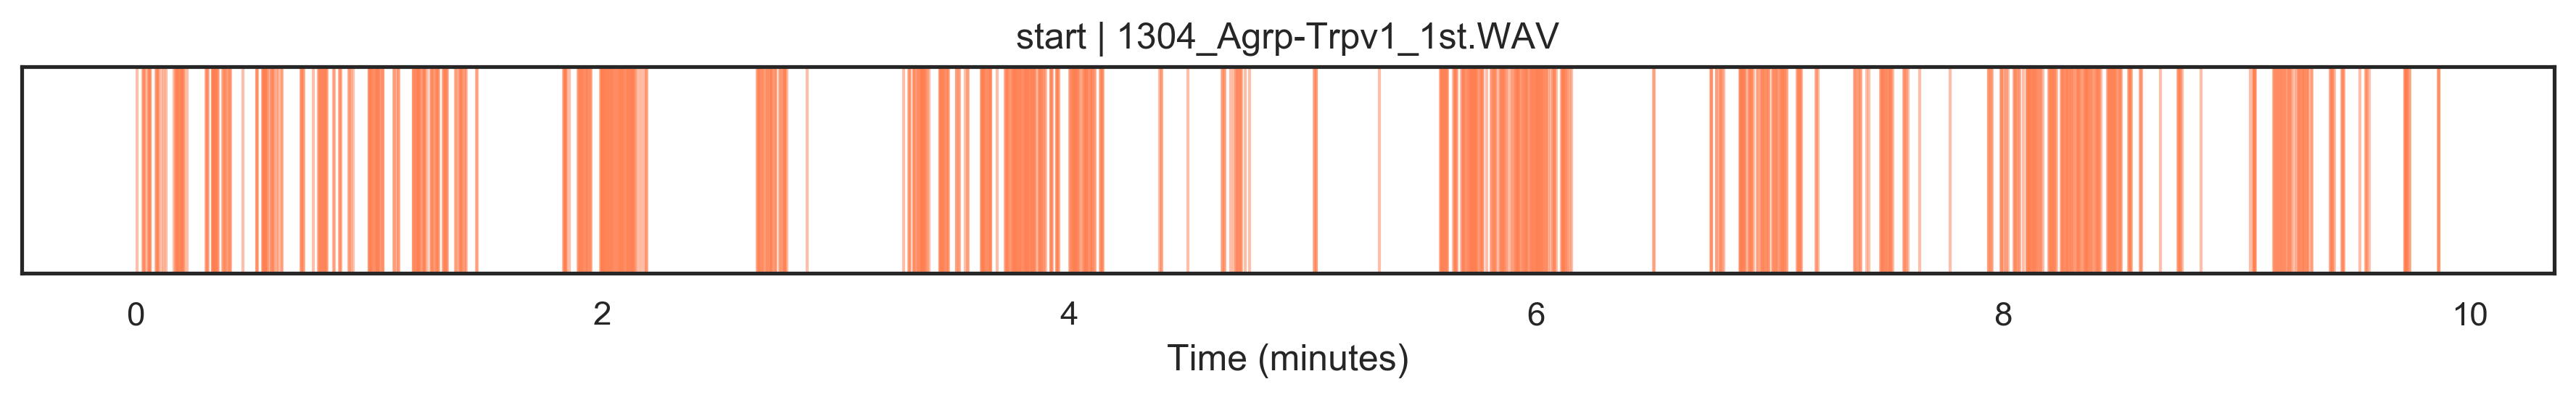

In [4]:
# -- visualize vocalizations throughtout the recording using a rug plot
dataname = 'start'
data = VizObj.rugplot(dataname)

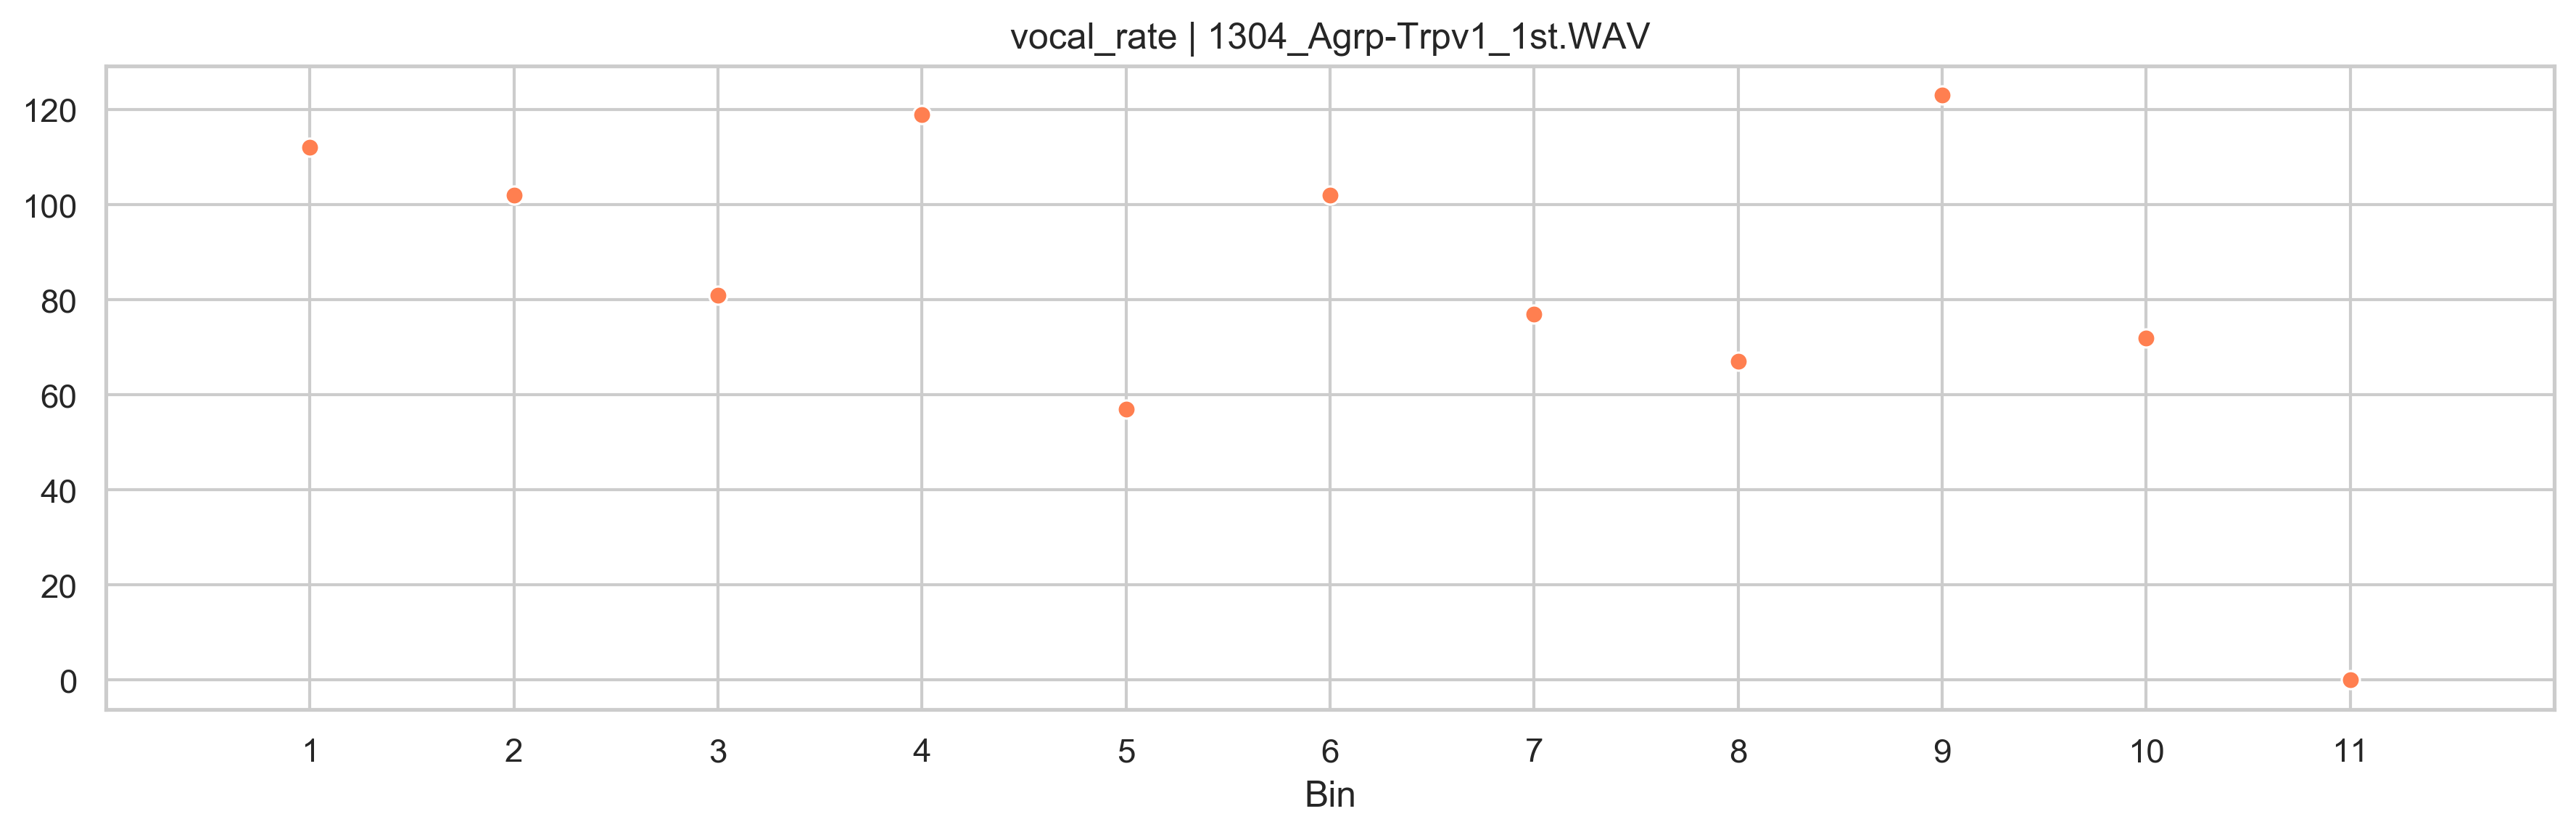

In [5]:
dataname = 'vocal_rate'
data = VizObj.scatter_count(dataname)

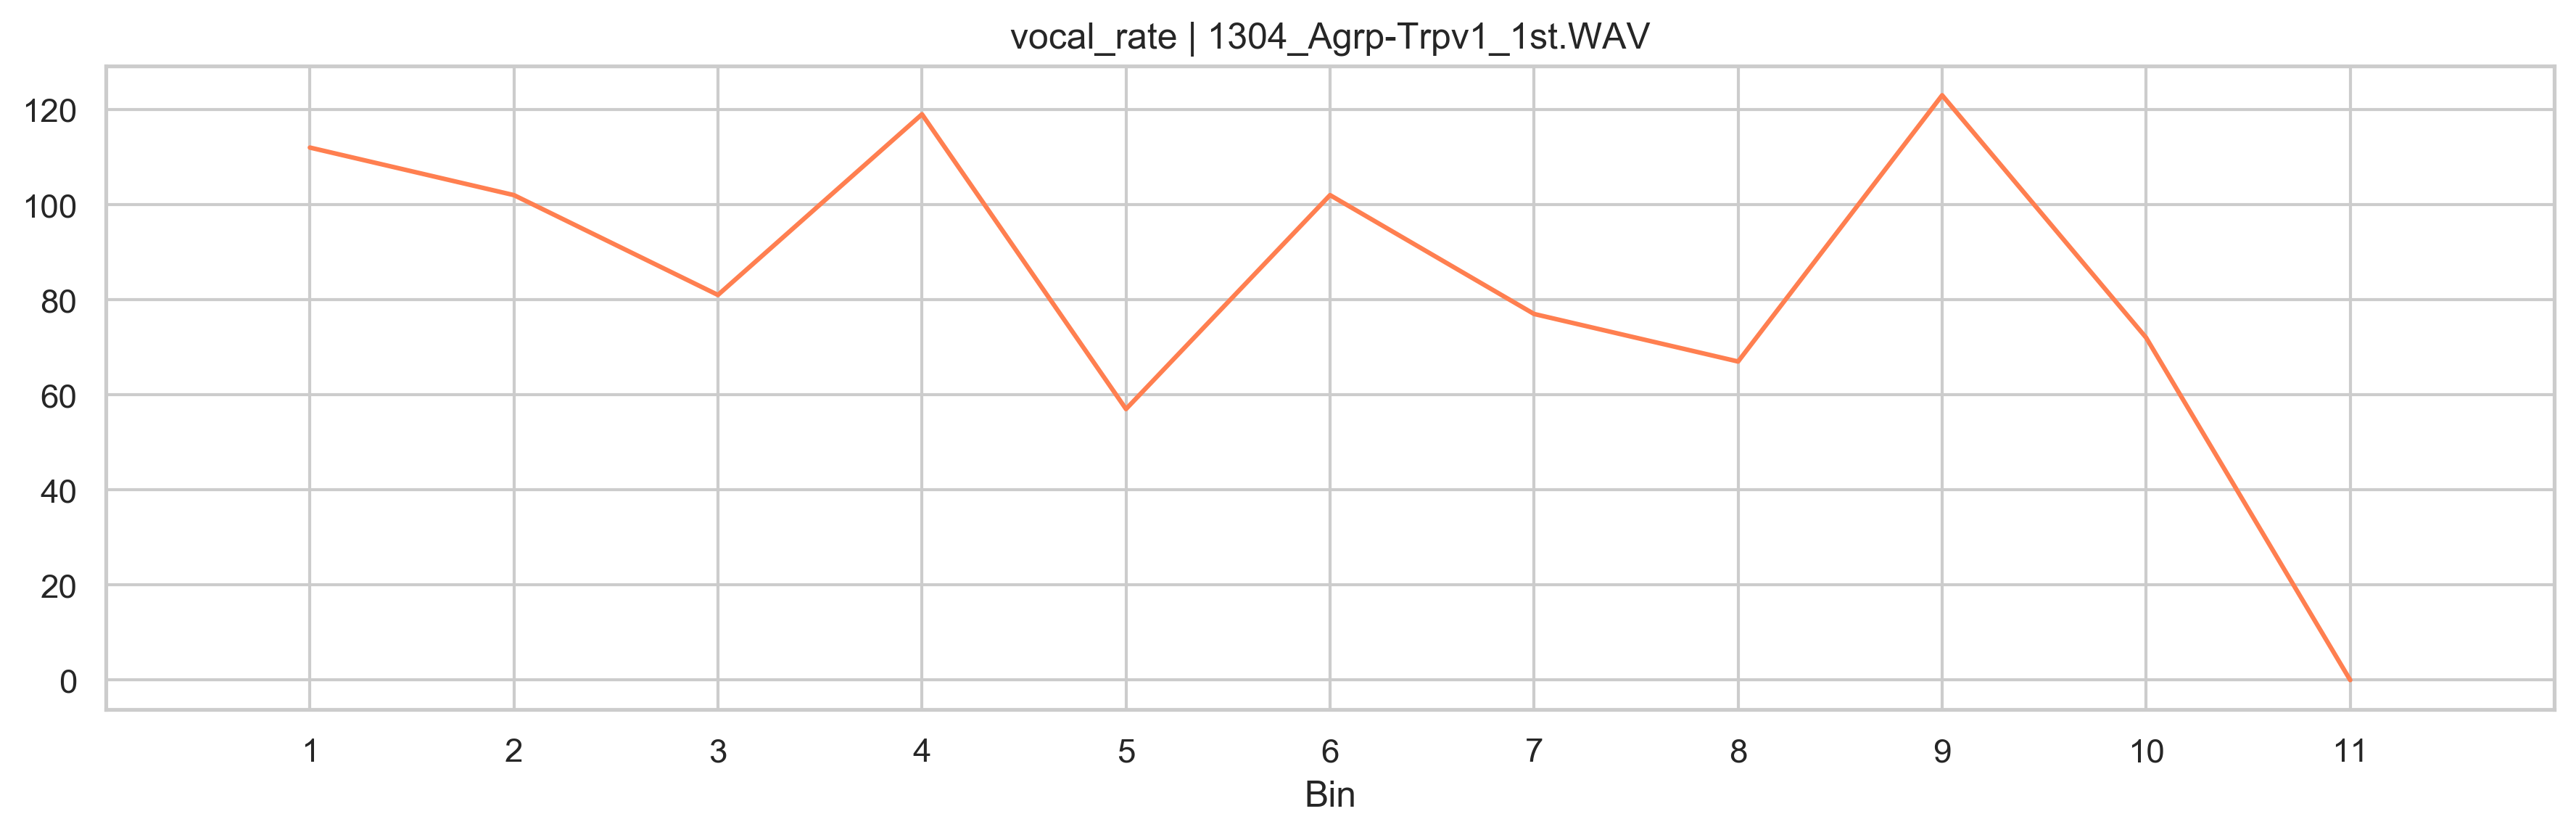

In [6]:
dataname = 'vocal_rate'
data = VizObj.lineplot_count(dataname)

../viz.py:74: RuntimeWarning: Mean of empty slice.
  return np.asarray([frame.mean() for frame in dataframe])
/Users/gustavo/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:85: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


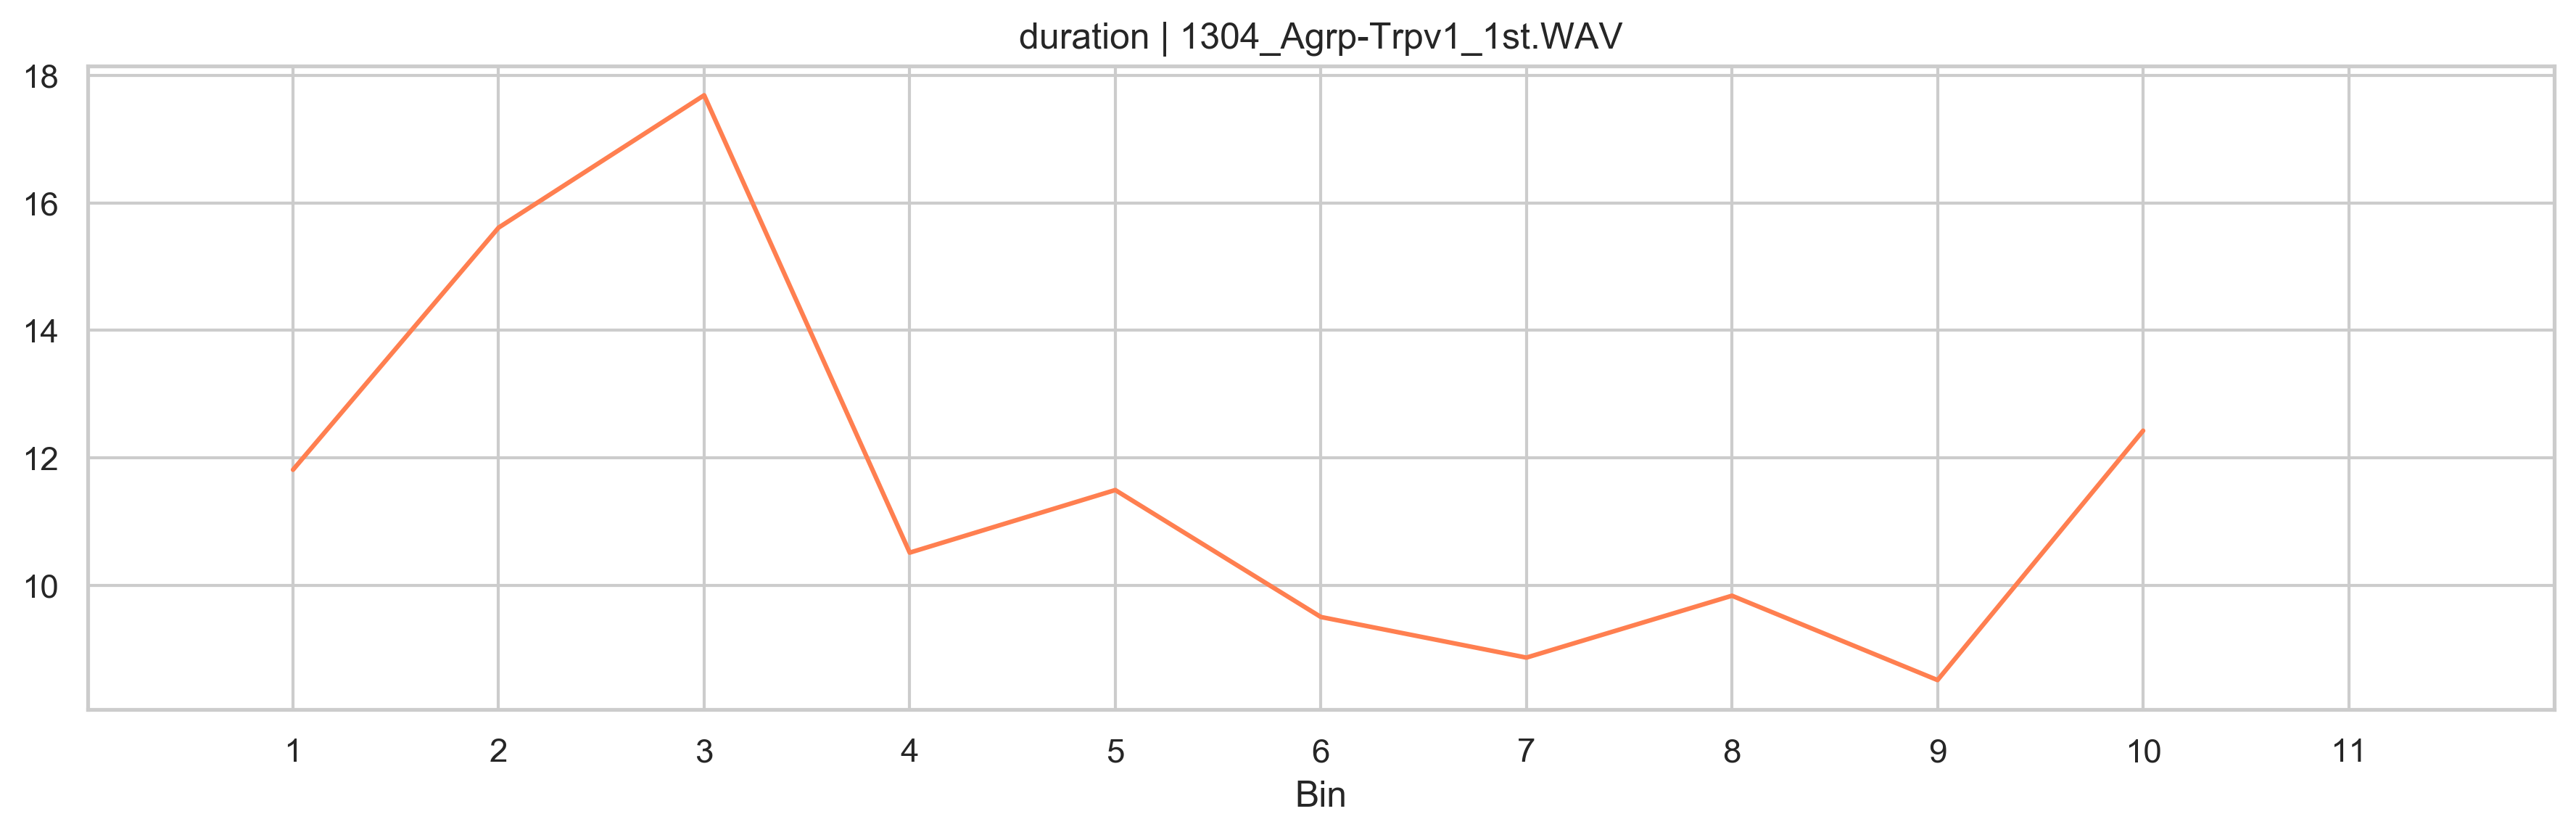

In [7]:
dataname = 'duration'
data = VizObj.lineplot_mean(dataname)

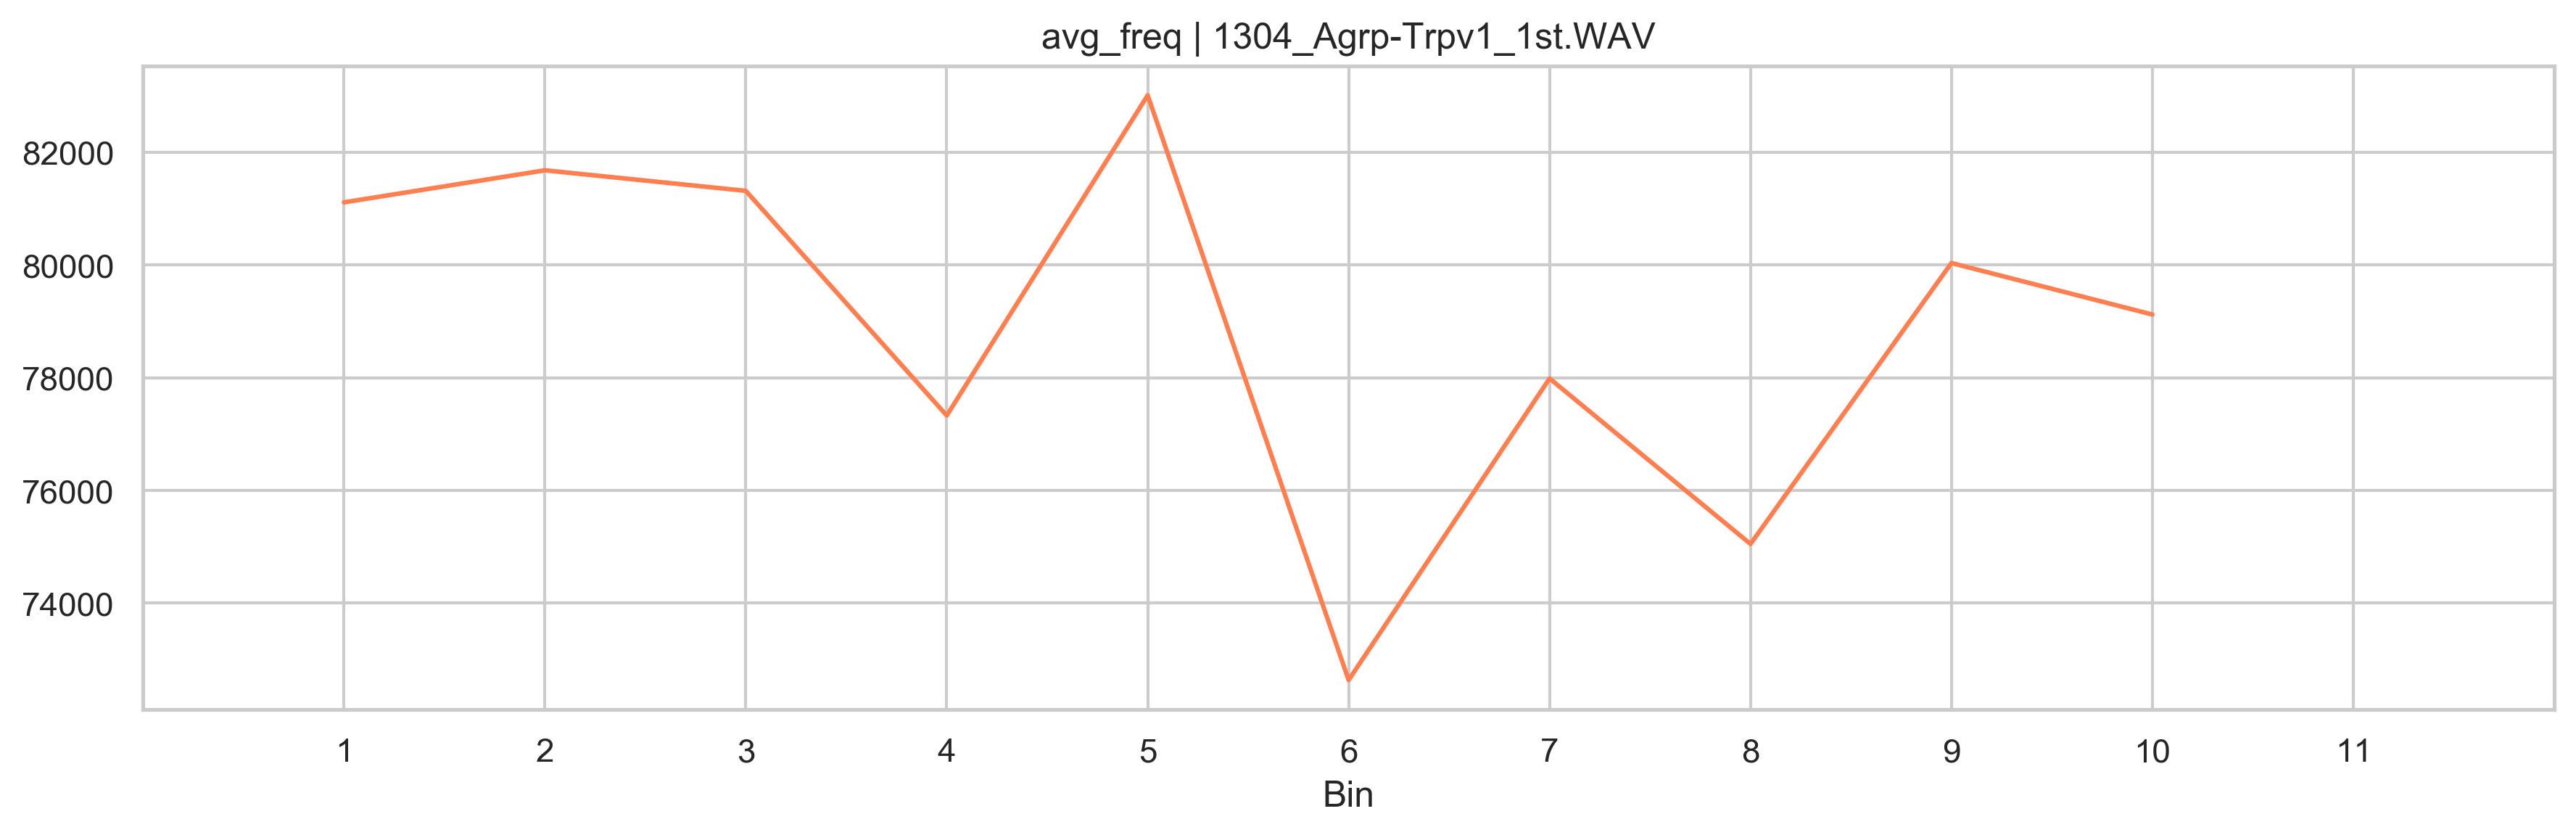

In [8]:
dataname = 'avg_freq'
data = VizObj.lineplot_mean(dataname)

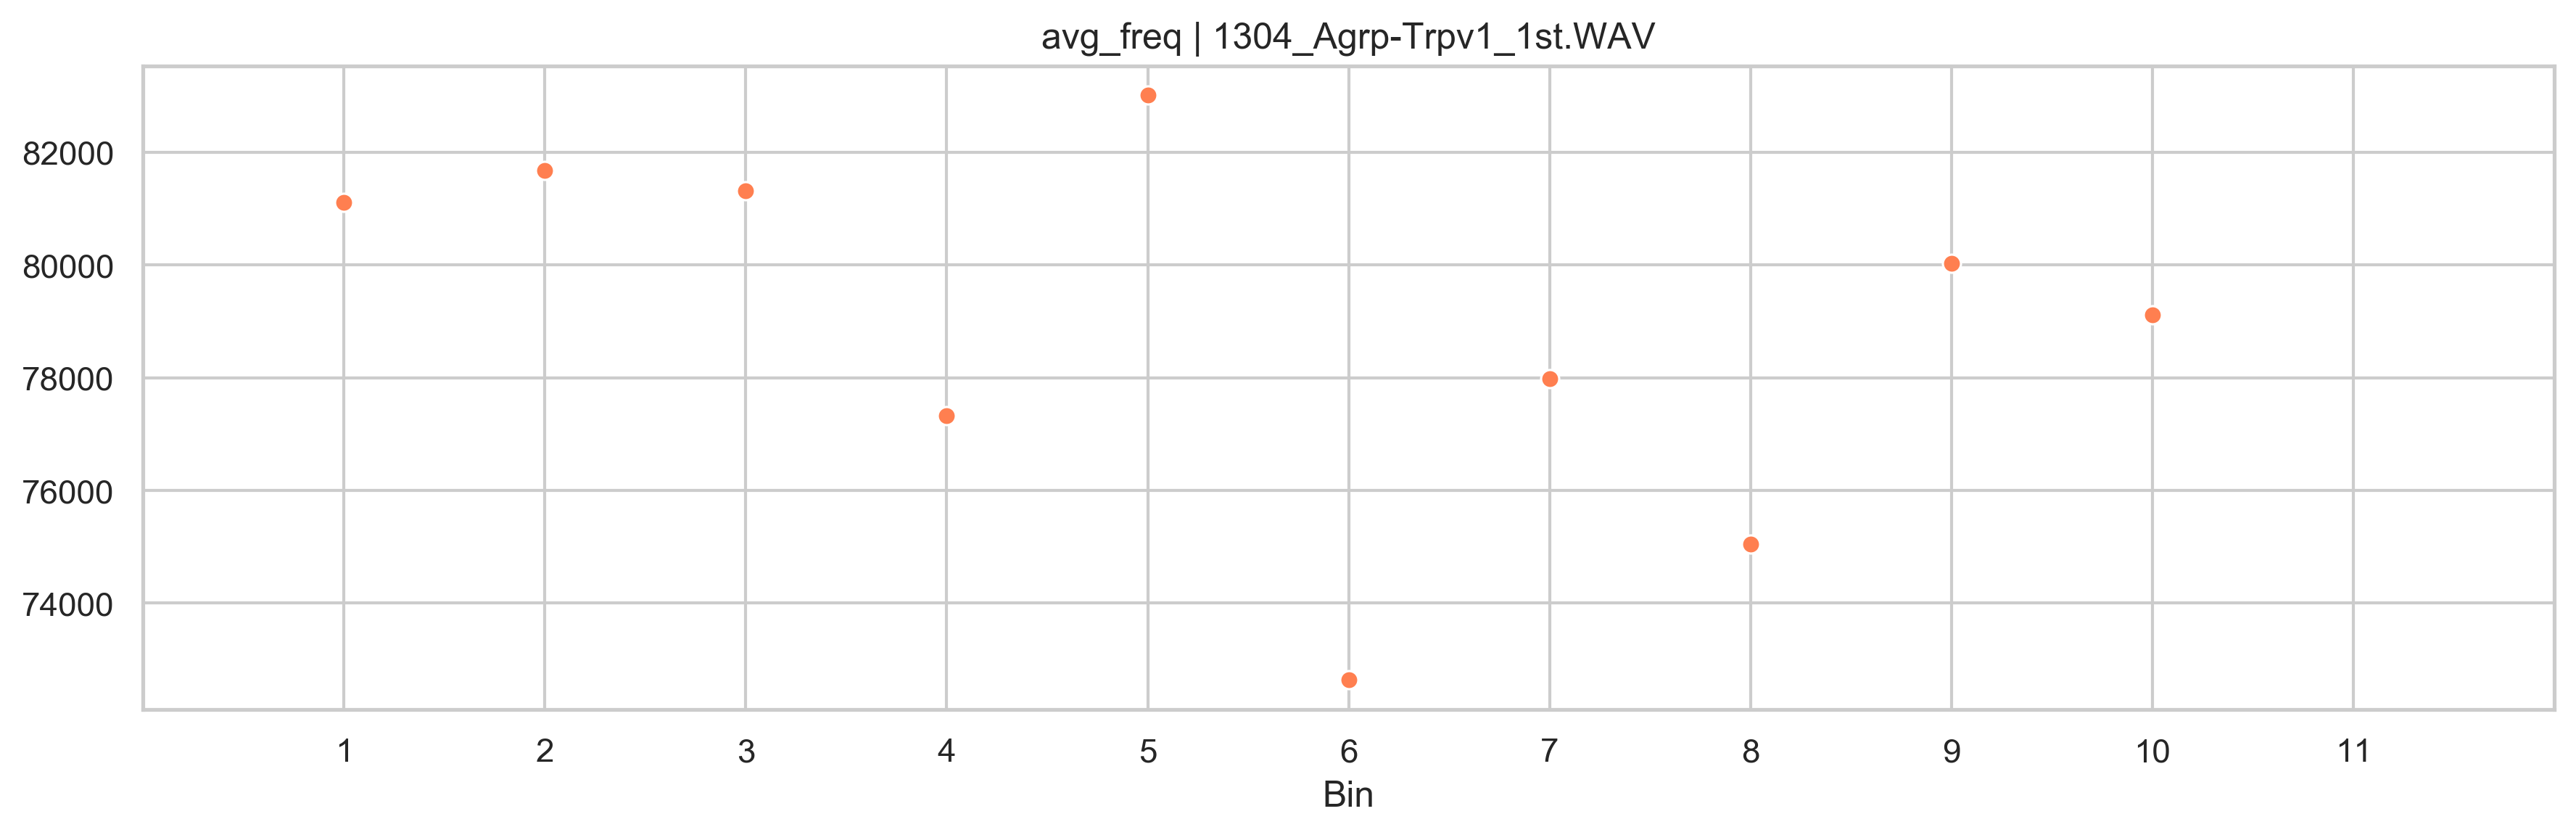

In [9]:
dataname = 'avg_freq'
data = VizObj.scatter_mean(dataname)

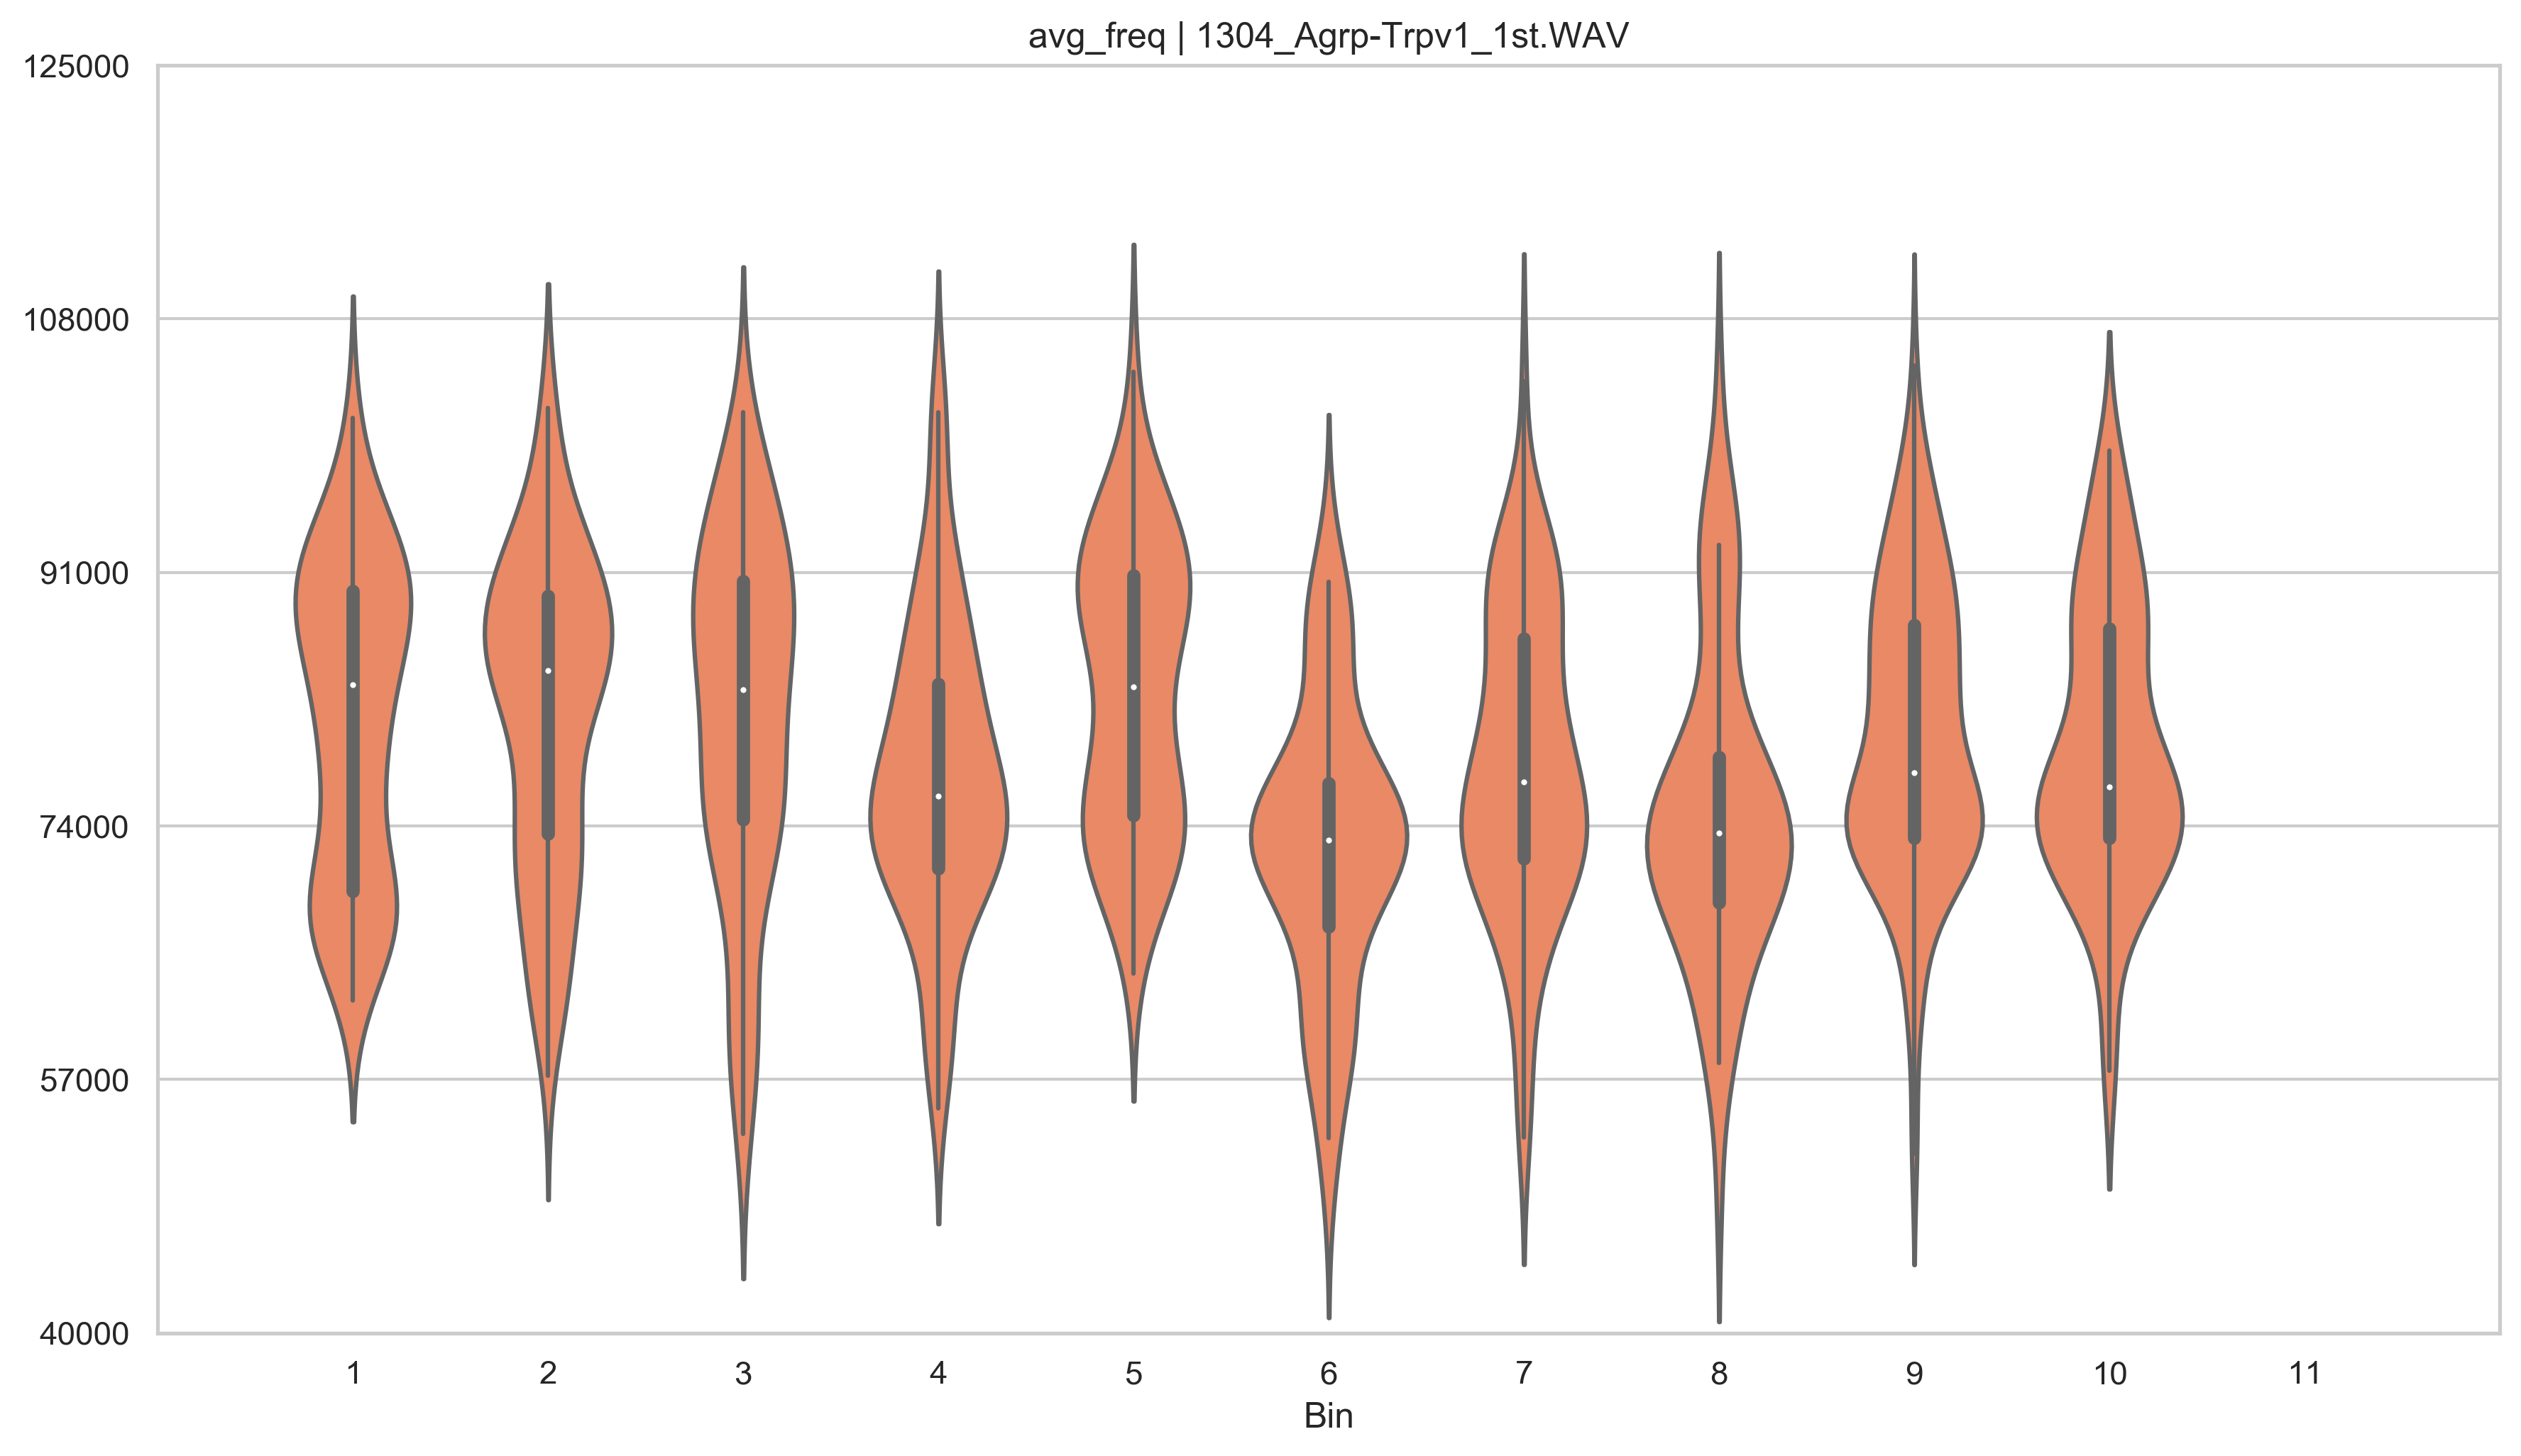

In [14]:
dataname = 'avg_freq'
data = VizObj.violinplot(dataname, inner='box')

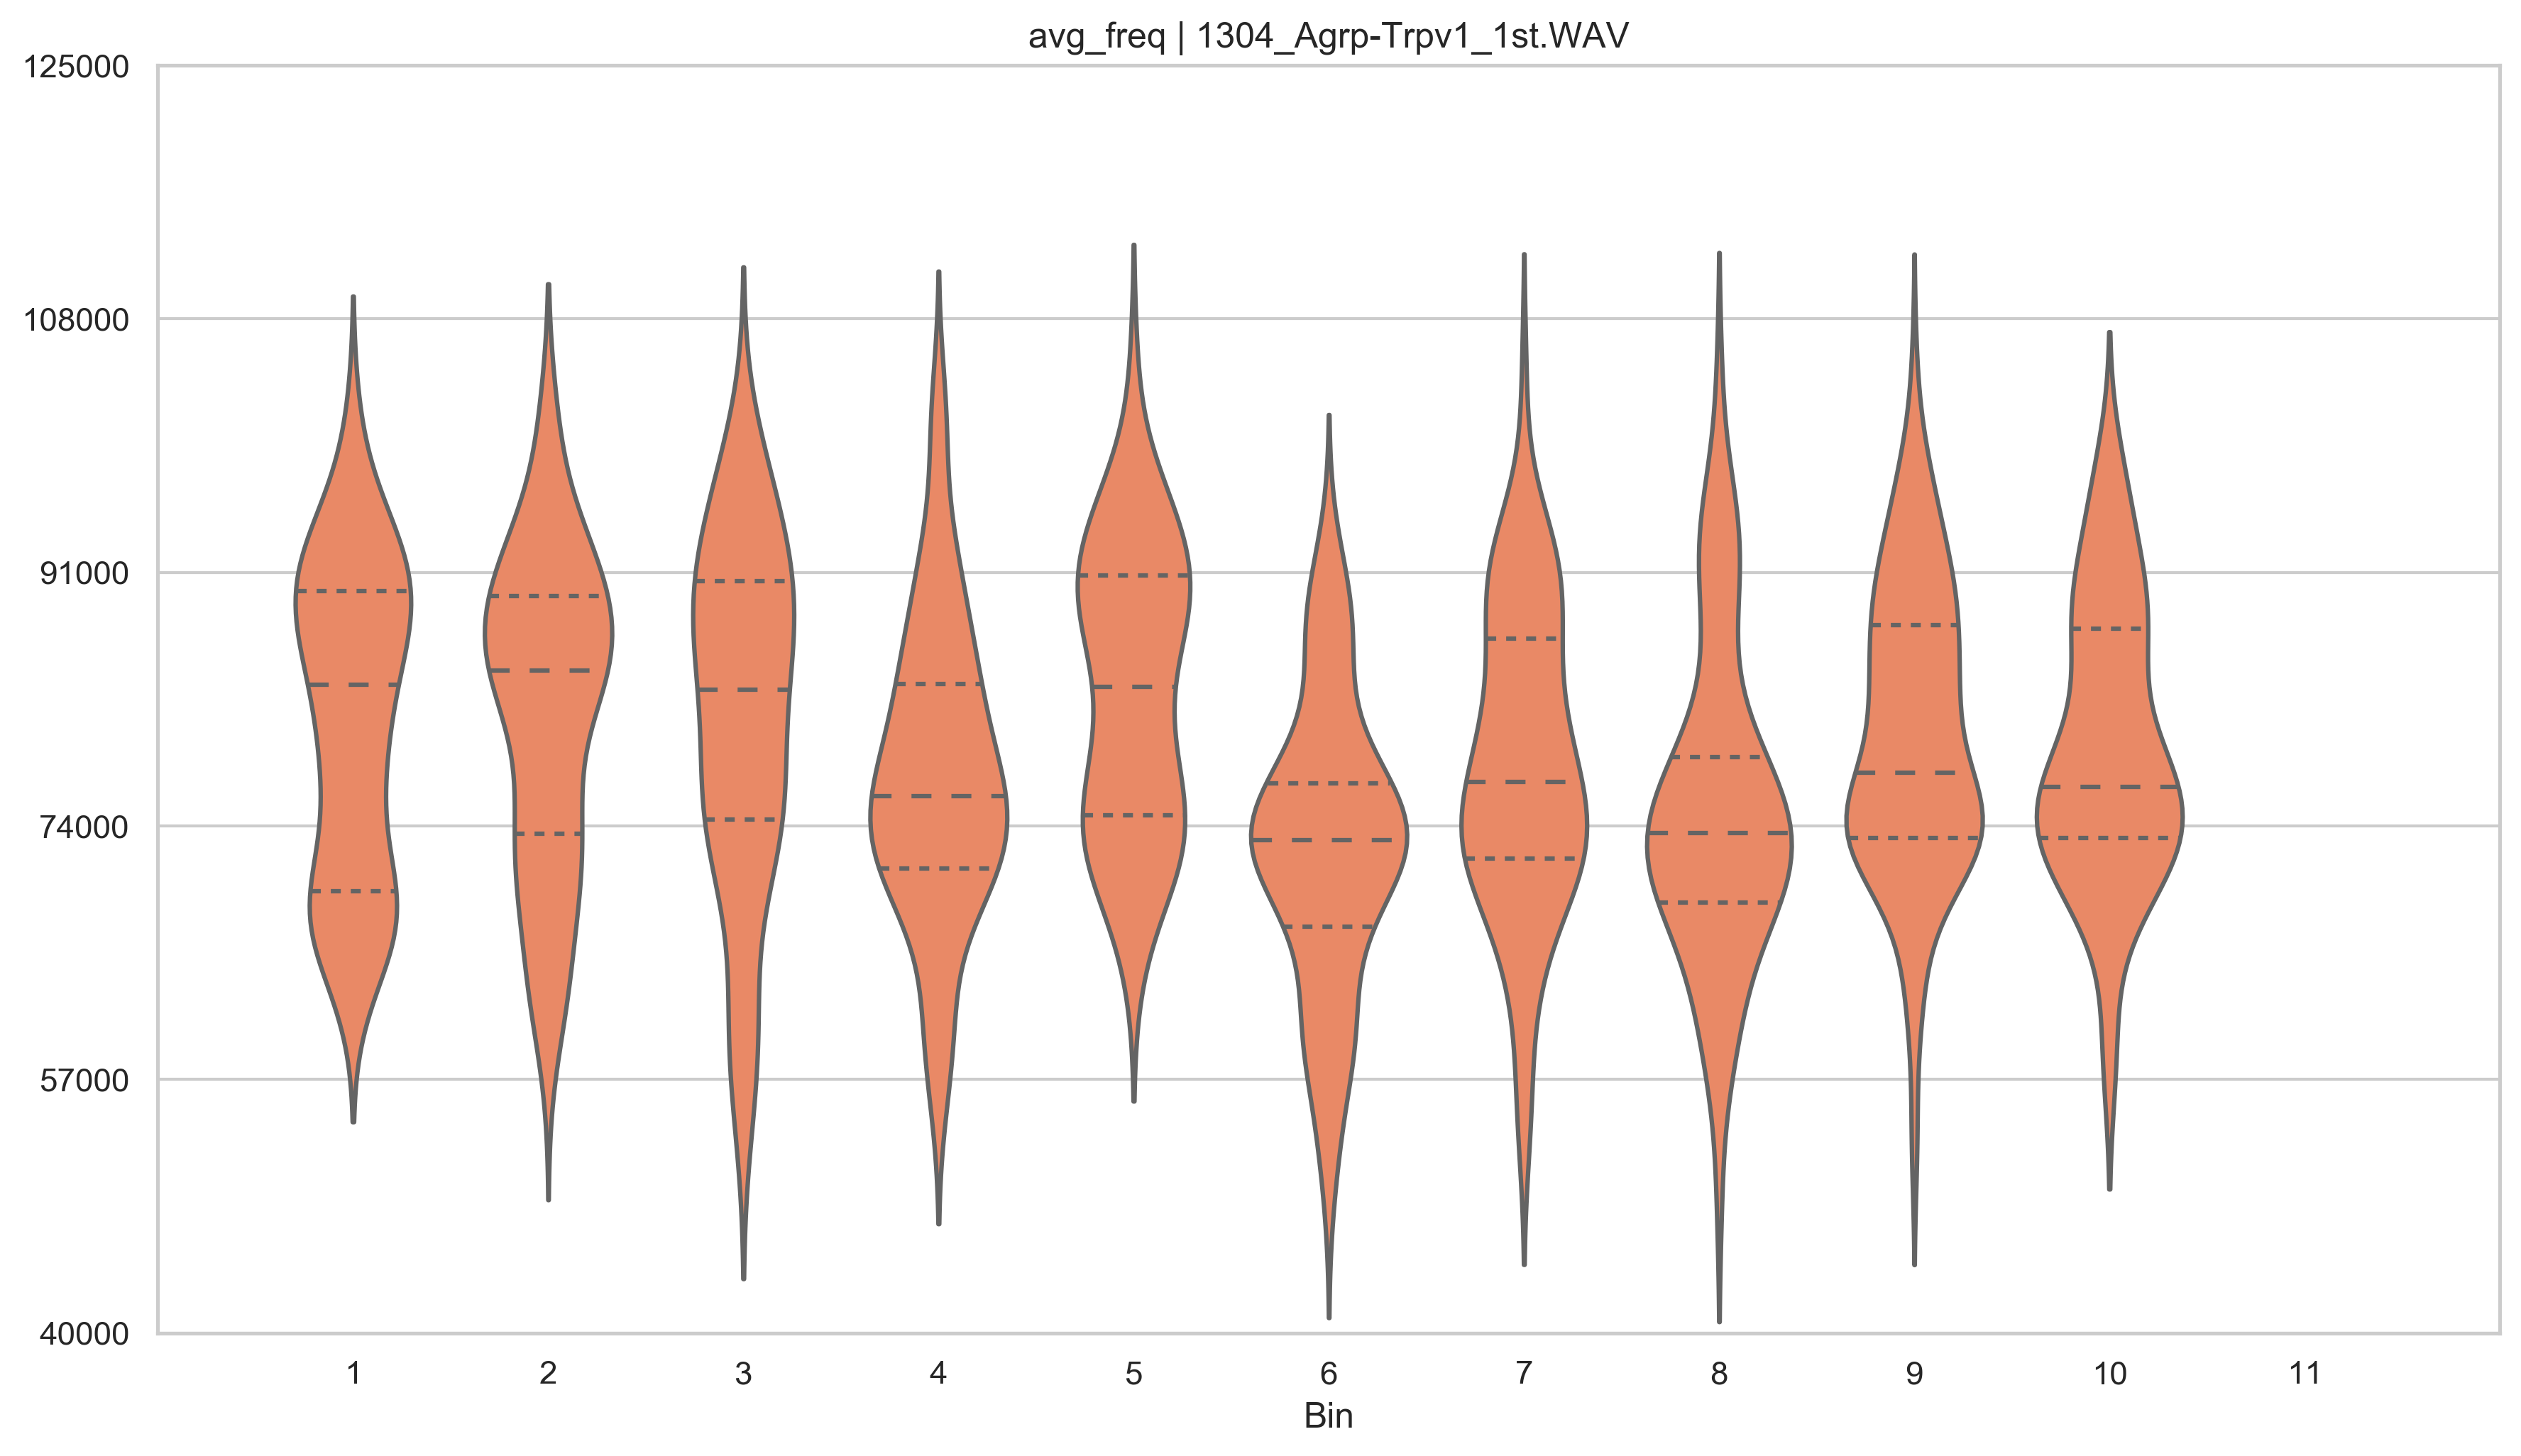

In [15]:
dataname = 'avg_freq'
data = VizObj.violinplot(dataname, inner='quartile')

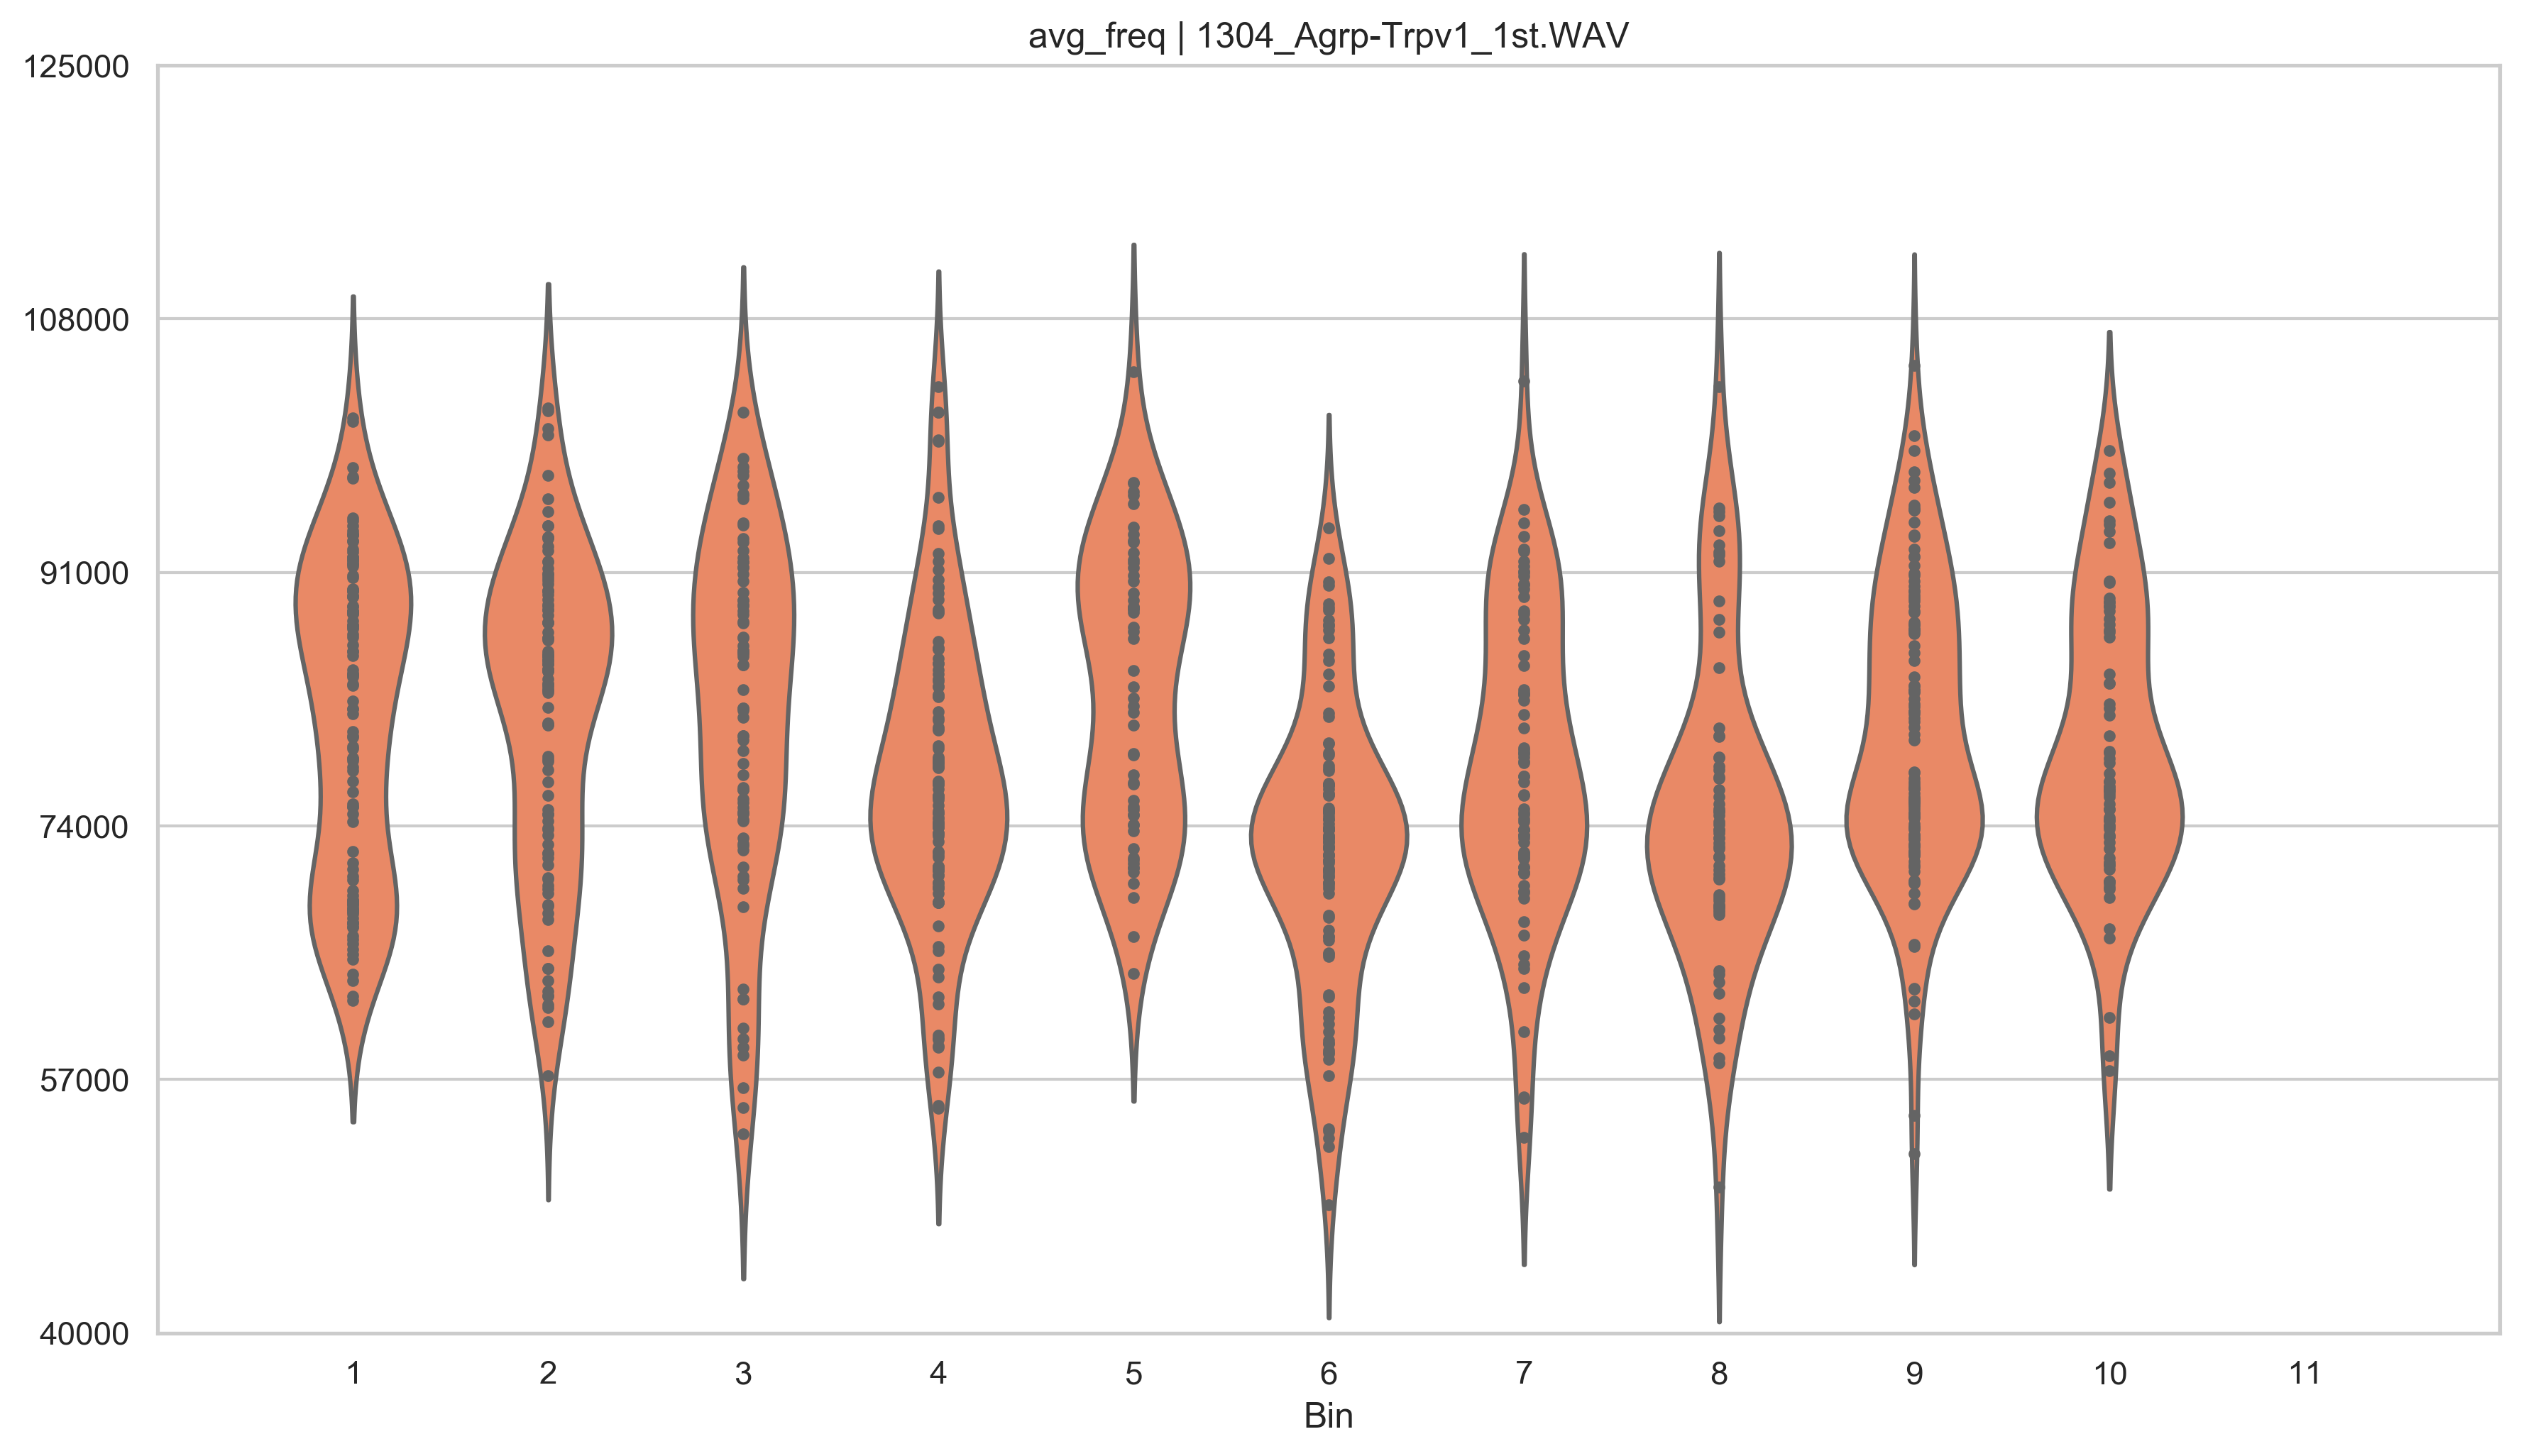

In [11]:
dataname = 'avg_freq'
data = VizObj.violinplot(dataname, inner='points')

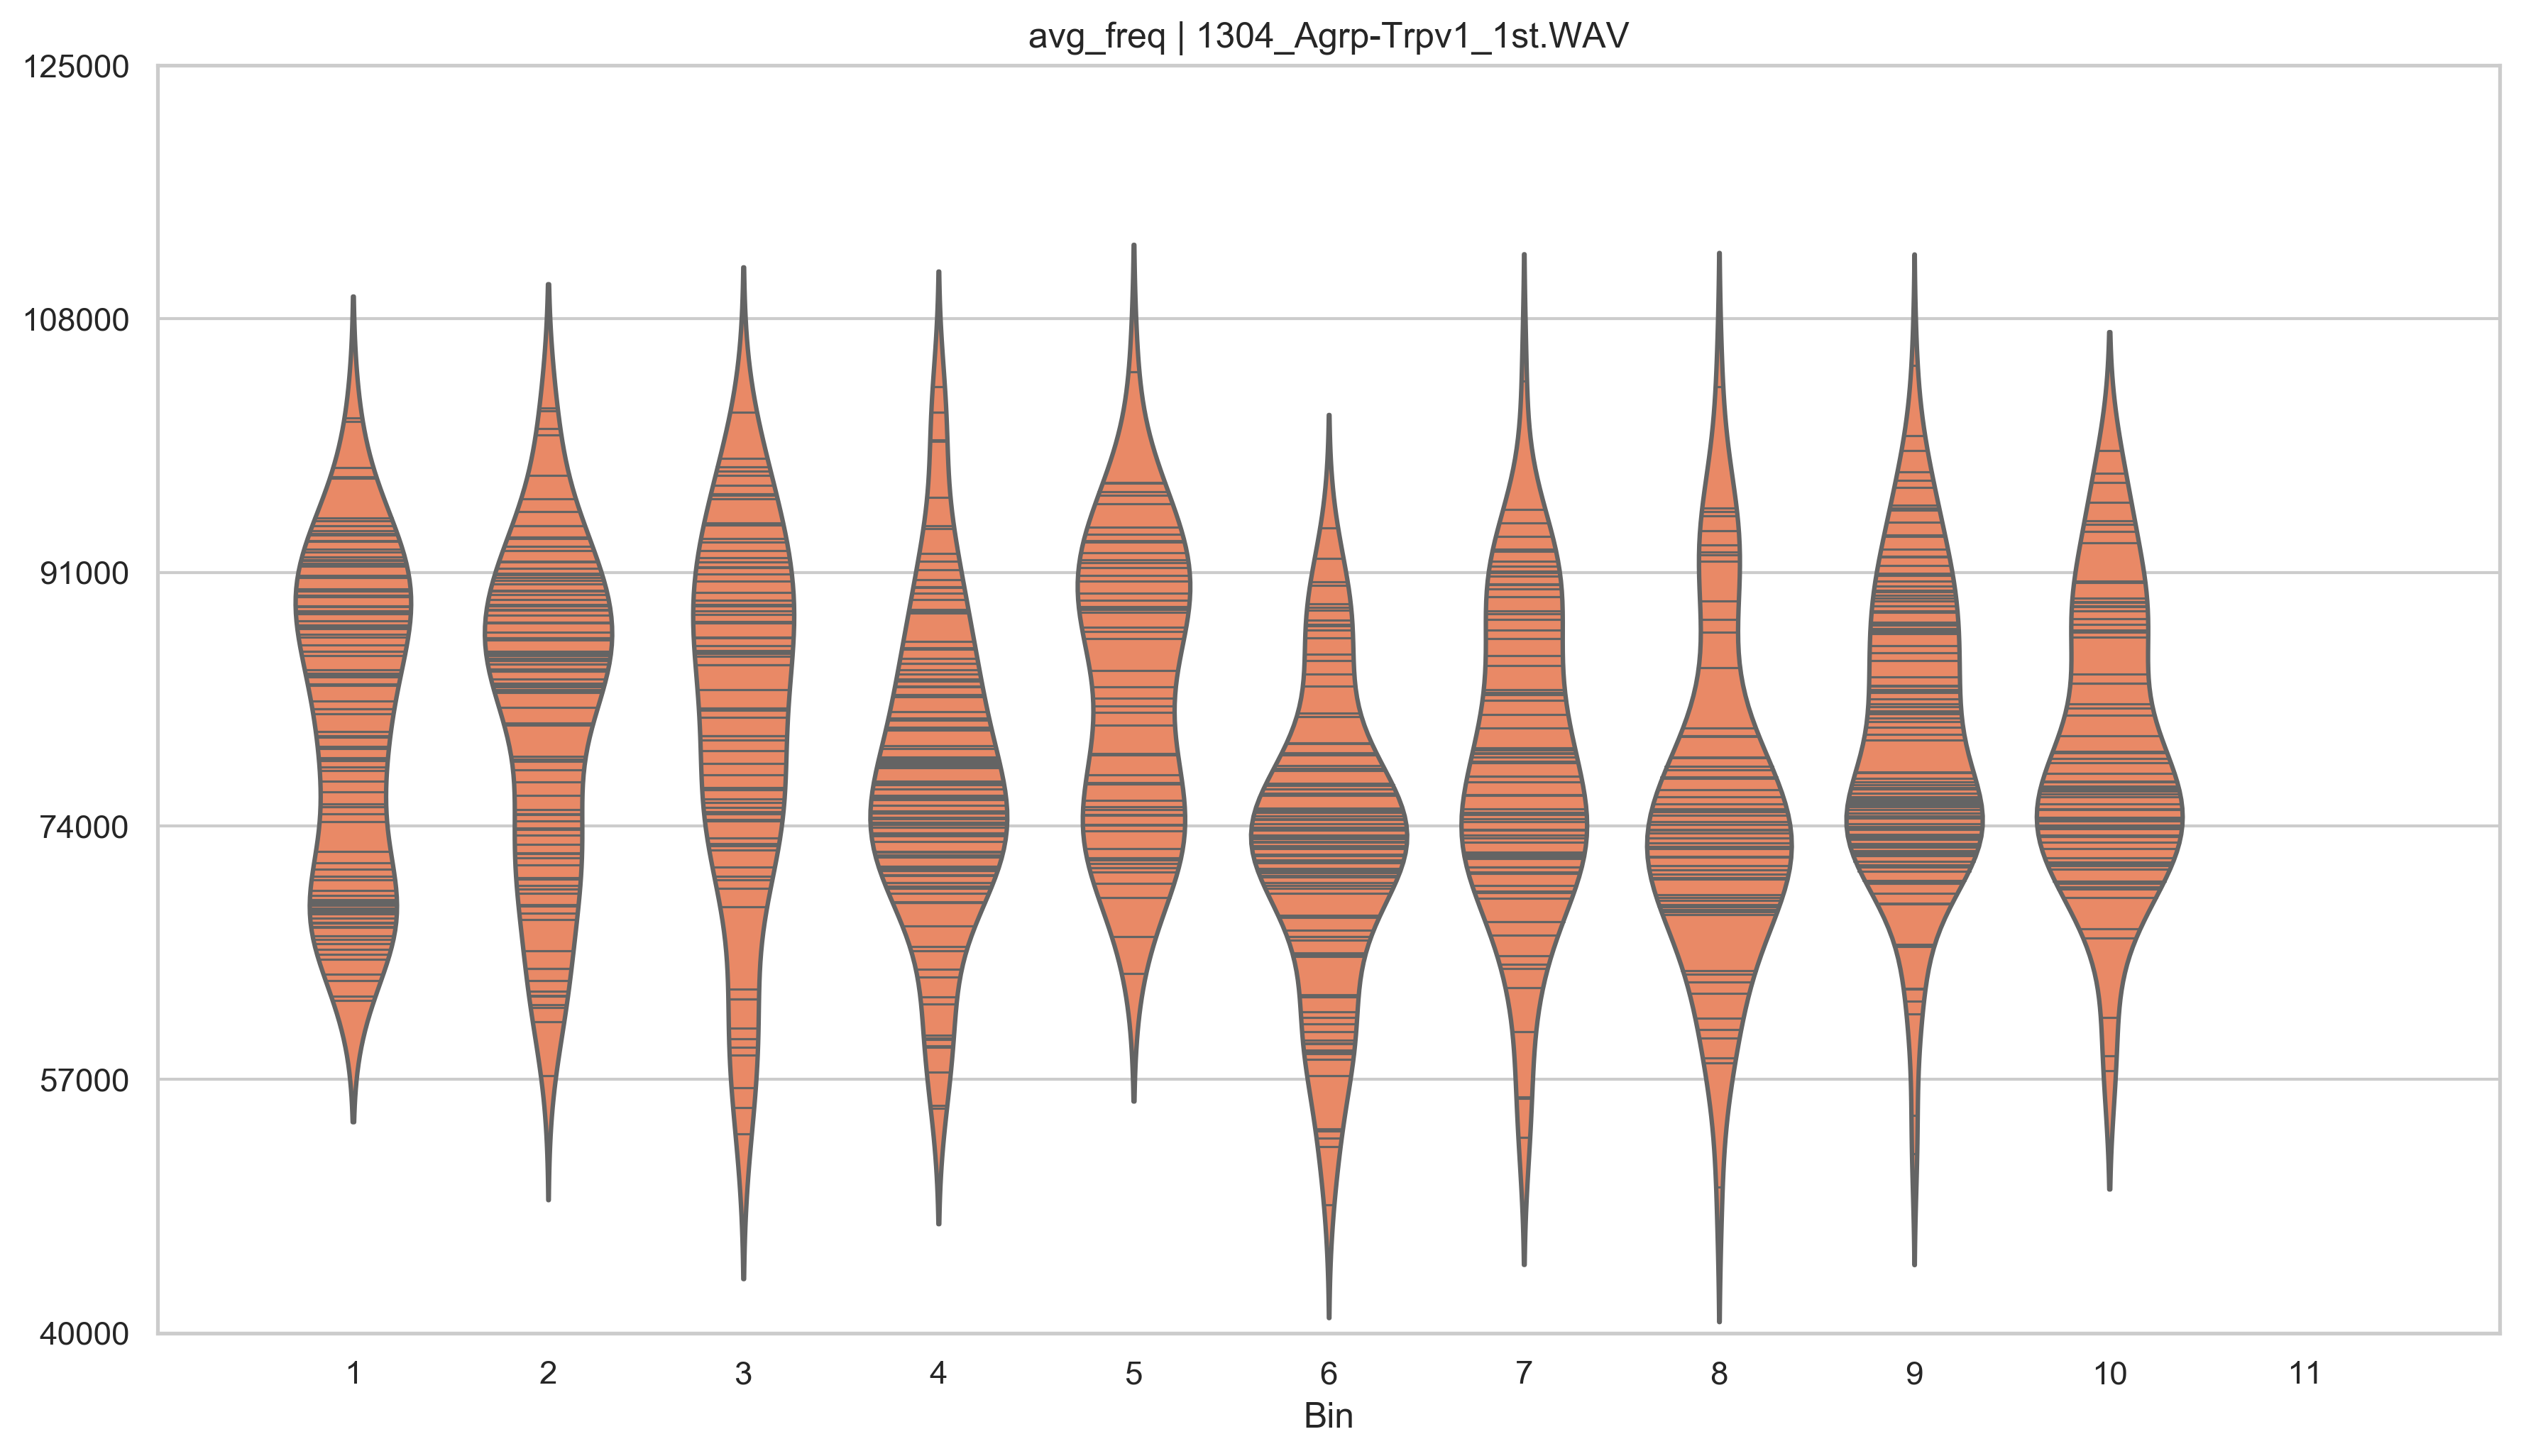

In [12]:
dataname = 'avg_freq'
data = VizObj.violinplot(dataname, inner='stick')

In [2]:
# -- First we load the output object from VocalPy for the desired recording

# -- path to vocalpy object
object_path = r'/Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording.vocalpy'
object_data = np.load(object_path, allow_pickle=True)
list_of_vocals = object_data._list_of_vocals

print("Object loaded for recording: {}".format(object_data.recording_path))
print("Recording duration: {:.2f} minutes".format(object_data.recording_duration/60))
print("Number of vocals: {}".format(list_of_vocals.number_of_vocals))

Object loaded for recording: /Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st.WAV
Recording duration: 10.02 minutes
Number of vocals: 912


In [3]:
# -- Convert vocal information into a table and visualize the results

recording_df = pd.DataFrame(columns = ['bin_number', 'start', 'end', 'duration', 'interval', 'min_freq', 'max_freq', 'avg_freq', 'bandwidth', 'min_intensity', 'max_intensity', 'avg_intensity', 'bg_intensity', 'area', 'centroid'])
for vocal in iter(list_of_vocals.vocals_in_recording):
    recording_df = recording_df.append({'bin_number': vocal.bin_number, 'start': vocal.start, 'end': vocal.end, 'duration': vocal.duration, 'interval': vocal.interval, 'min_freq': vocal.min_freq, 'max_freq': vocal.max_freq, 'avg_freq': vocal.avg_freq, 'bandwidth': vocal.bandwidth, 'min_intensity': vocal.min_intensity, 'max_intensity': vocal.max_intensity, 'avg_intensity': vocal.avg_intensity, 'bg_intensity': vocal.bg_intensity, 'area': vocal.area, 'centroid': vocal.centroid}, ignore_index=True)

print("Recording contens:\n")
recording_df

Recording contens:



,bin_number,start,end,duration,interval,min_freq,max_freq,avg_freq,bandwidth,min_intensity,max_intensity,avg_intensity,bg_intensity,area,centroid
0,1,0.380422,0.385542,5.120085,0,64268.292683,72560.975610,68440.308087,8292.682927,-135.284640,-83.223811,-108.929876,-121.434836,266,"[96, 200]"
1,1,2.009121,2.017314,8.192137,1623.58,61585.365854,71341.463415,67519.647696,9756.097561,-136.514341,-82.658868,-107.860870,-121.178754,360,"[92, 200]"
2,1,2.135588,2.145316,9.728162,118.274,64756.097561,74268.292683,69347.259116,9512.195122,-144.963254,-77.404769,-104.206725,-121.105308,505,"[100, 200]"
3,1,2.318375,2.334759,16.384273,173.059,58902.439024,71341.463415,65741.668679,12439.024390,-145.363797,-78.546298,-105.210432,-121.052014,808,"[85, 200]"
4,1,2.459177,2.470441,11.264188,124.418,70609.756098,80365.853659,75460.641729,9756.097561,-142.572437,-85.123726,-109.468813,-121.208303,431,"[125, 200]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,10,584.362296,584.394552,32.256413,402.437,88170.731707,99878.048780,94231.447846,11707.317073,-144.556701,-87.253975,-104.810602,-121.124636,940,"[202, 200]"
908,10,584.581947,584.613691,31.744406,187.394,85975.609756,110121.951220,97624.568437,24146.341463,-137.717182,-84.435657,-104.251566,-121.114336,1095,"[216, 200]"
909,10,591.804311,591.846296,41.984537,7190.62,83780.487805,94512.195122,89003.916682,10731.707317,-137.258298,-78.408296,-97.036794,-120.962311,1096,"[180, 200]"
910,10,592.026010,592.067994,41.984537,179.714,73292.682927,89390.243902,81902.988804,16097.560976,-137.876101,-90.217779,-105.839393,-121.060352,976,"[151, 200]"


In [4]:
def get_split_indices_for_bin_size(dataframe, bin_size, duration):
    bins = duration // bin_size
    
    split_array = []
    
    for idx in range(1, int(bins)+1):
        split_array.append(np.where(dataframe==idx*bin_size)[0][-1]+1)
    
    return split_array


def split_data_by_indices(dataframe, split_array):
    return np.asarray(np.split(dataframe, split_array))

def get_count_in_list_of_lists(dataframe):
    return [frame.shape[0] for frame in dataframe]

def get_mean_in_list_of_lists(dataframe):
    return [frame.mean() for frame in dataframe]

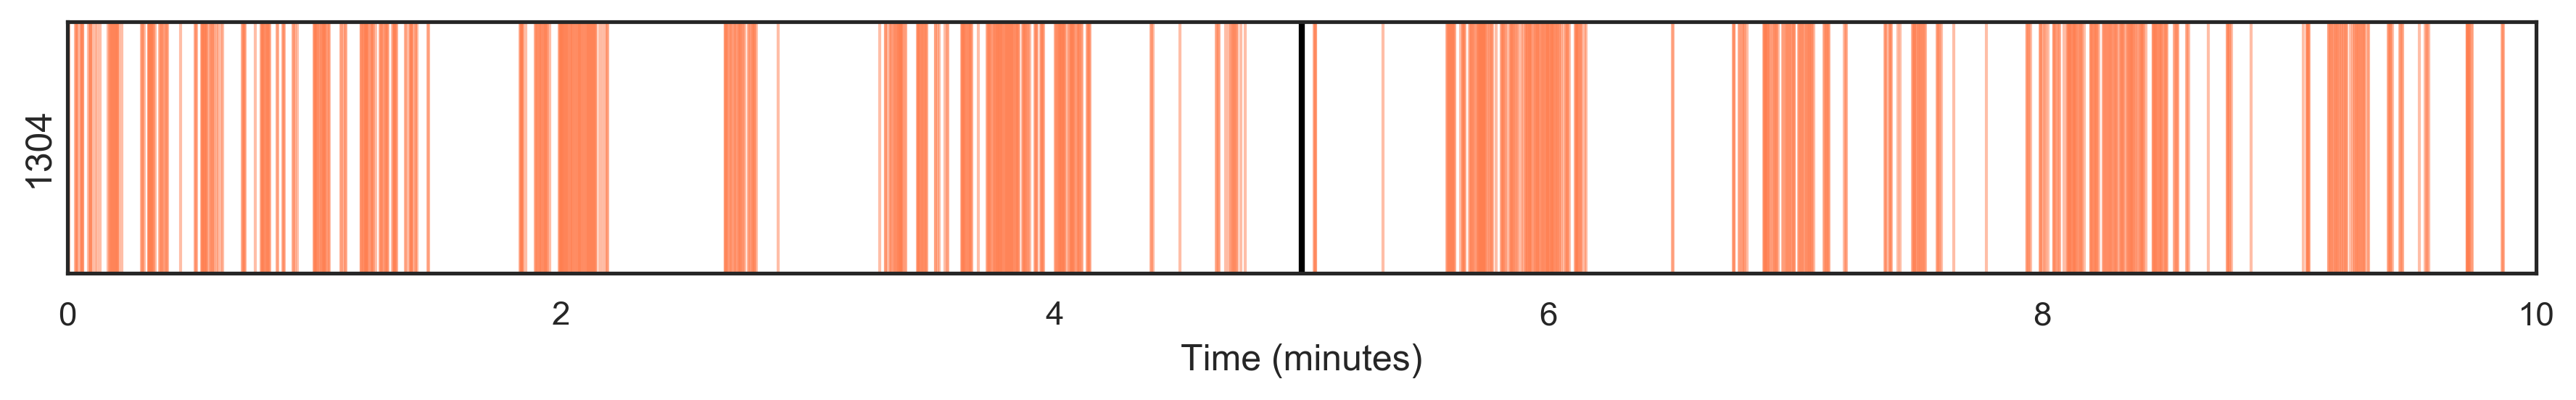

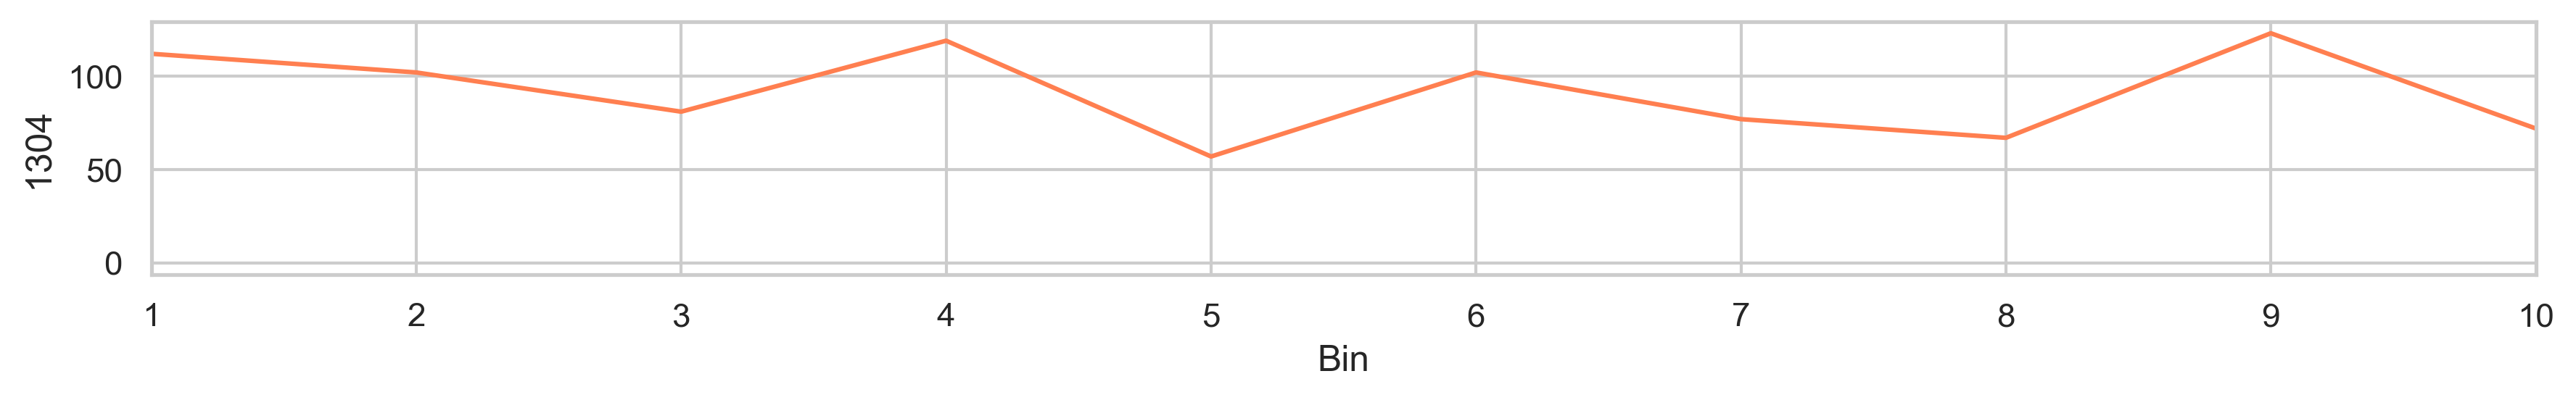

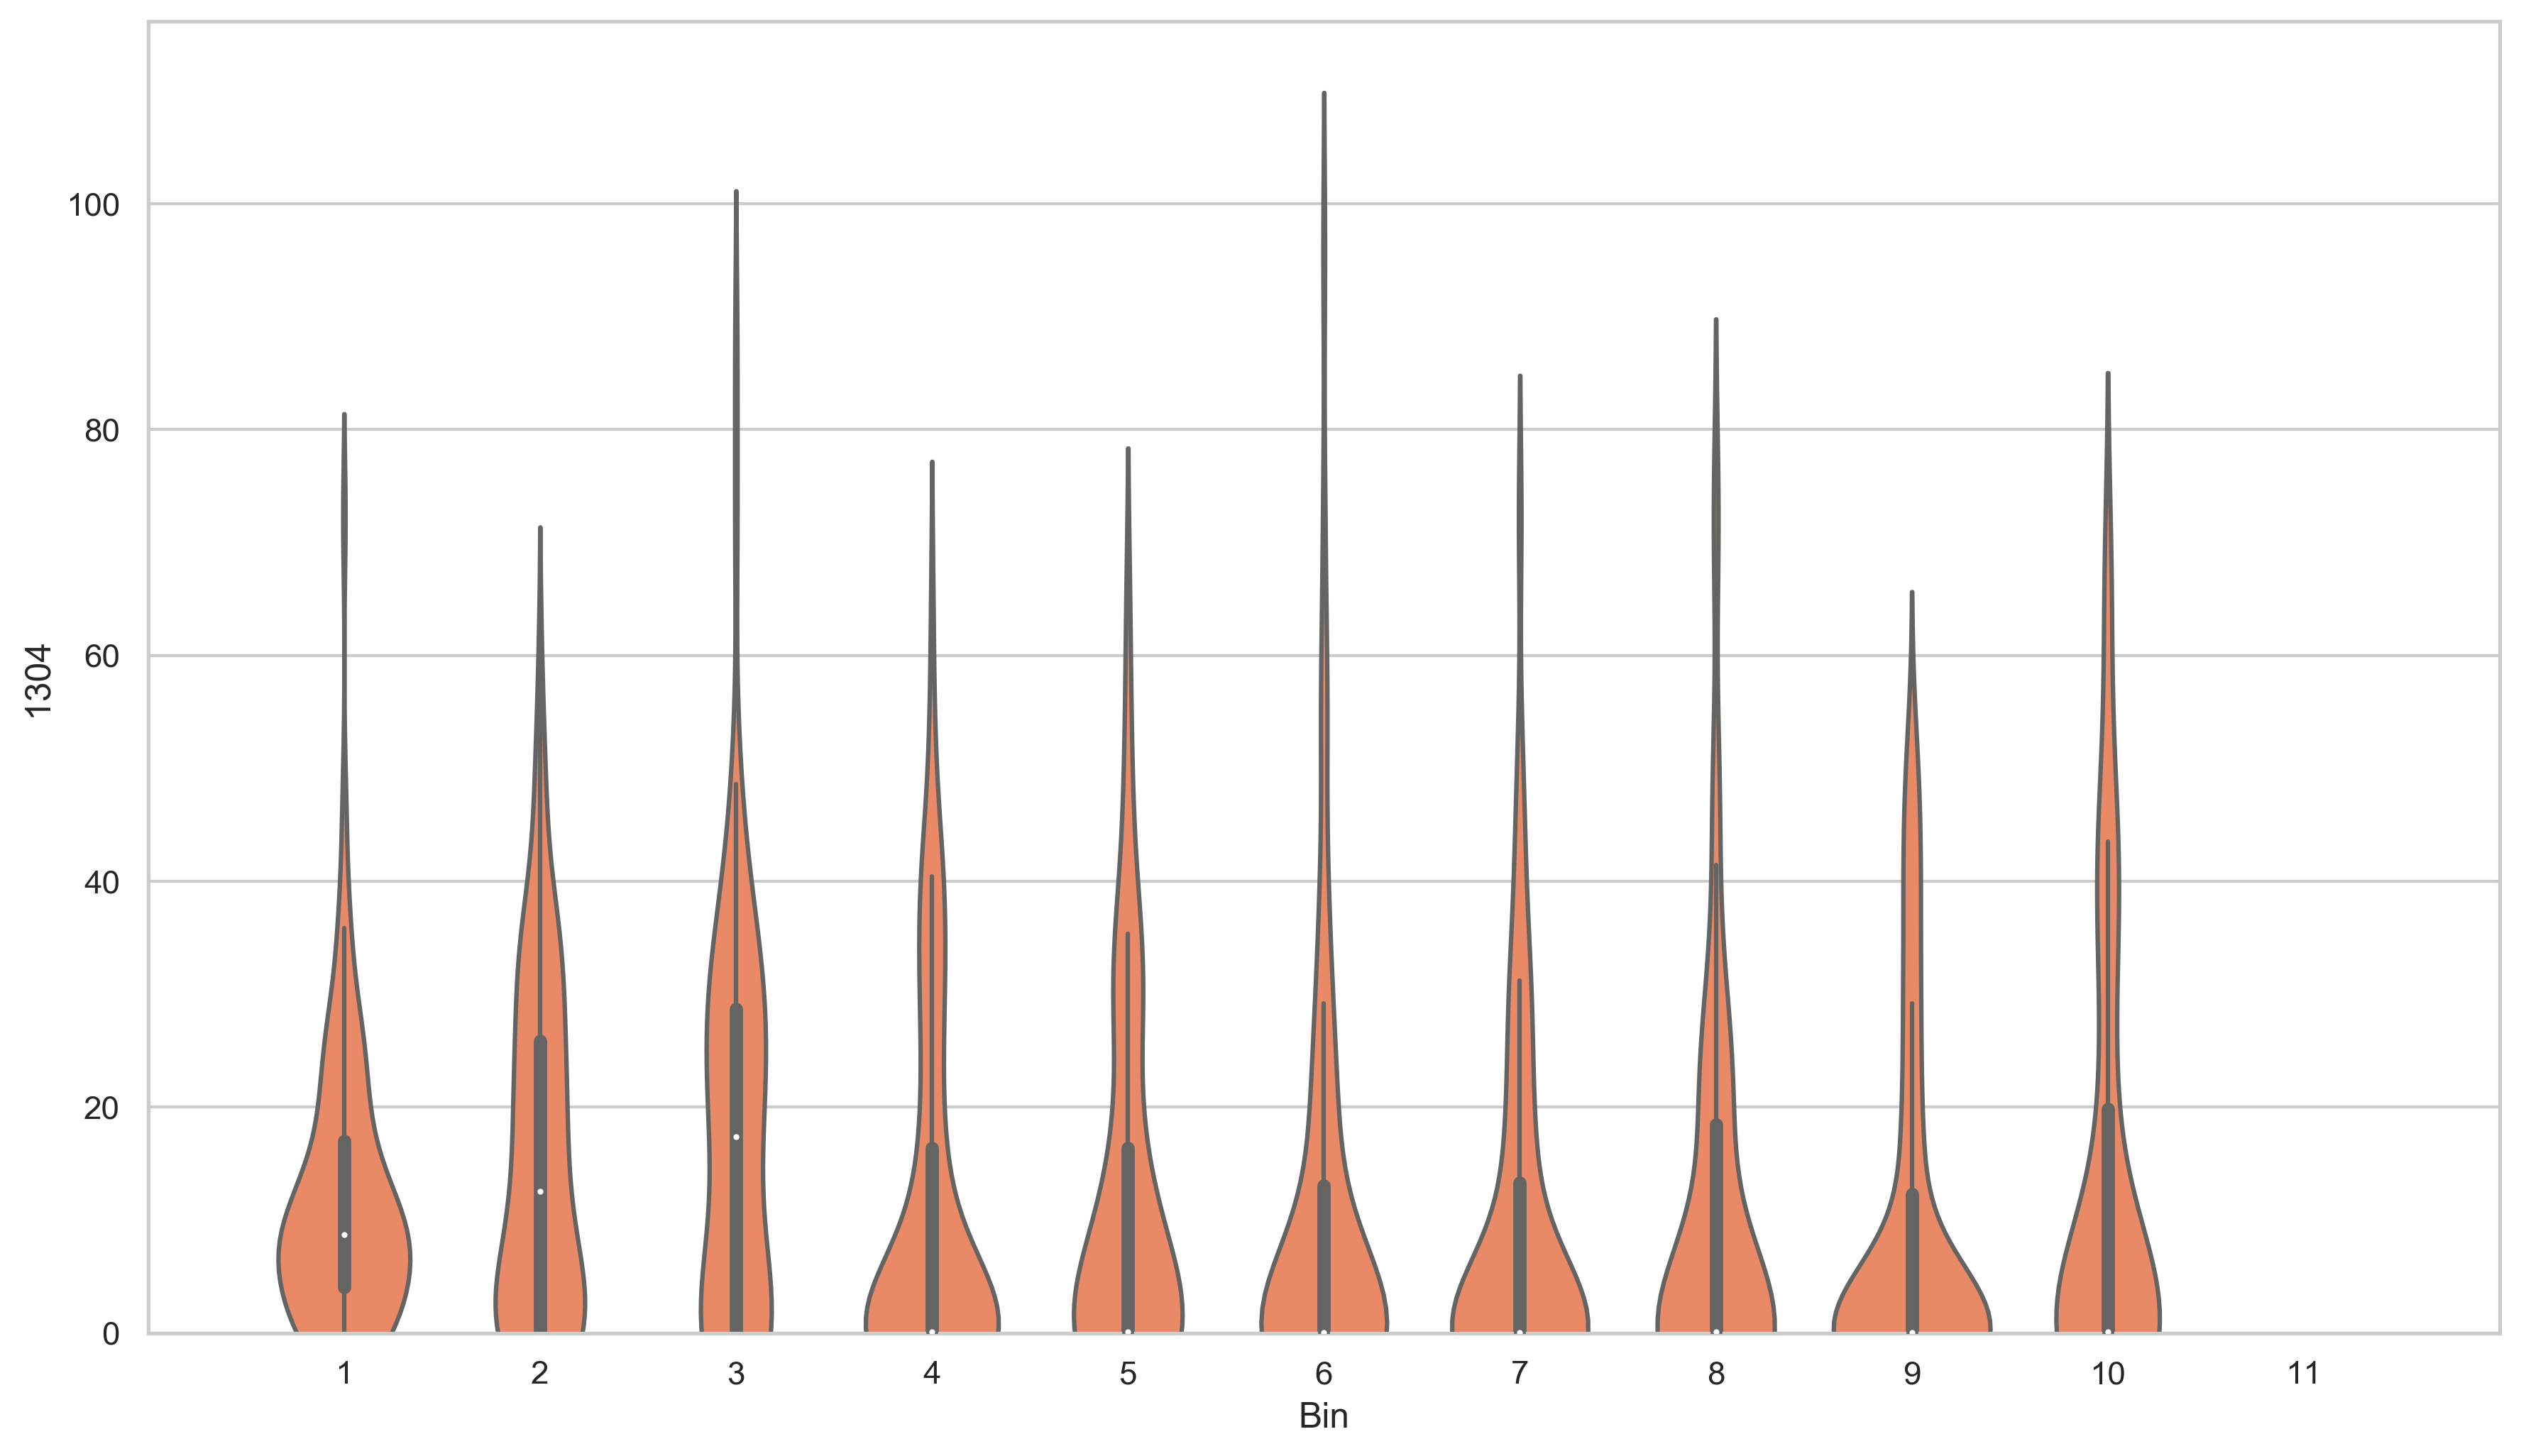

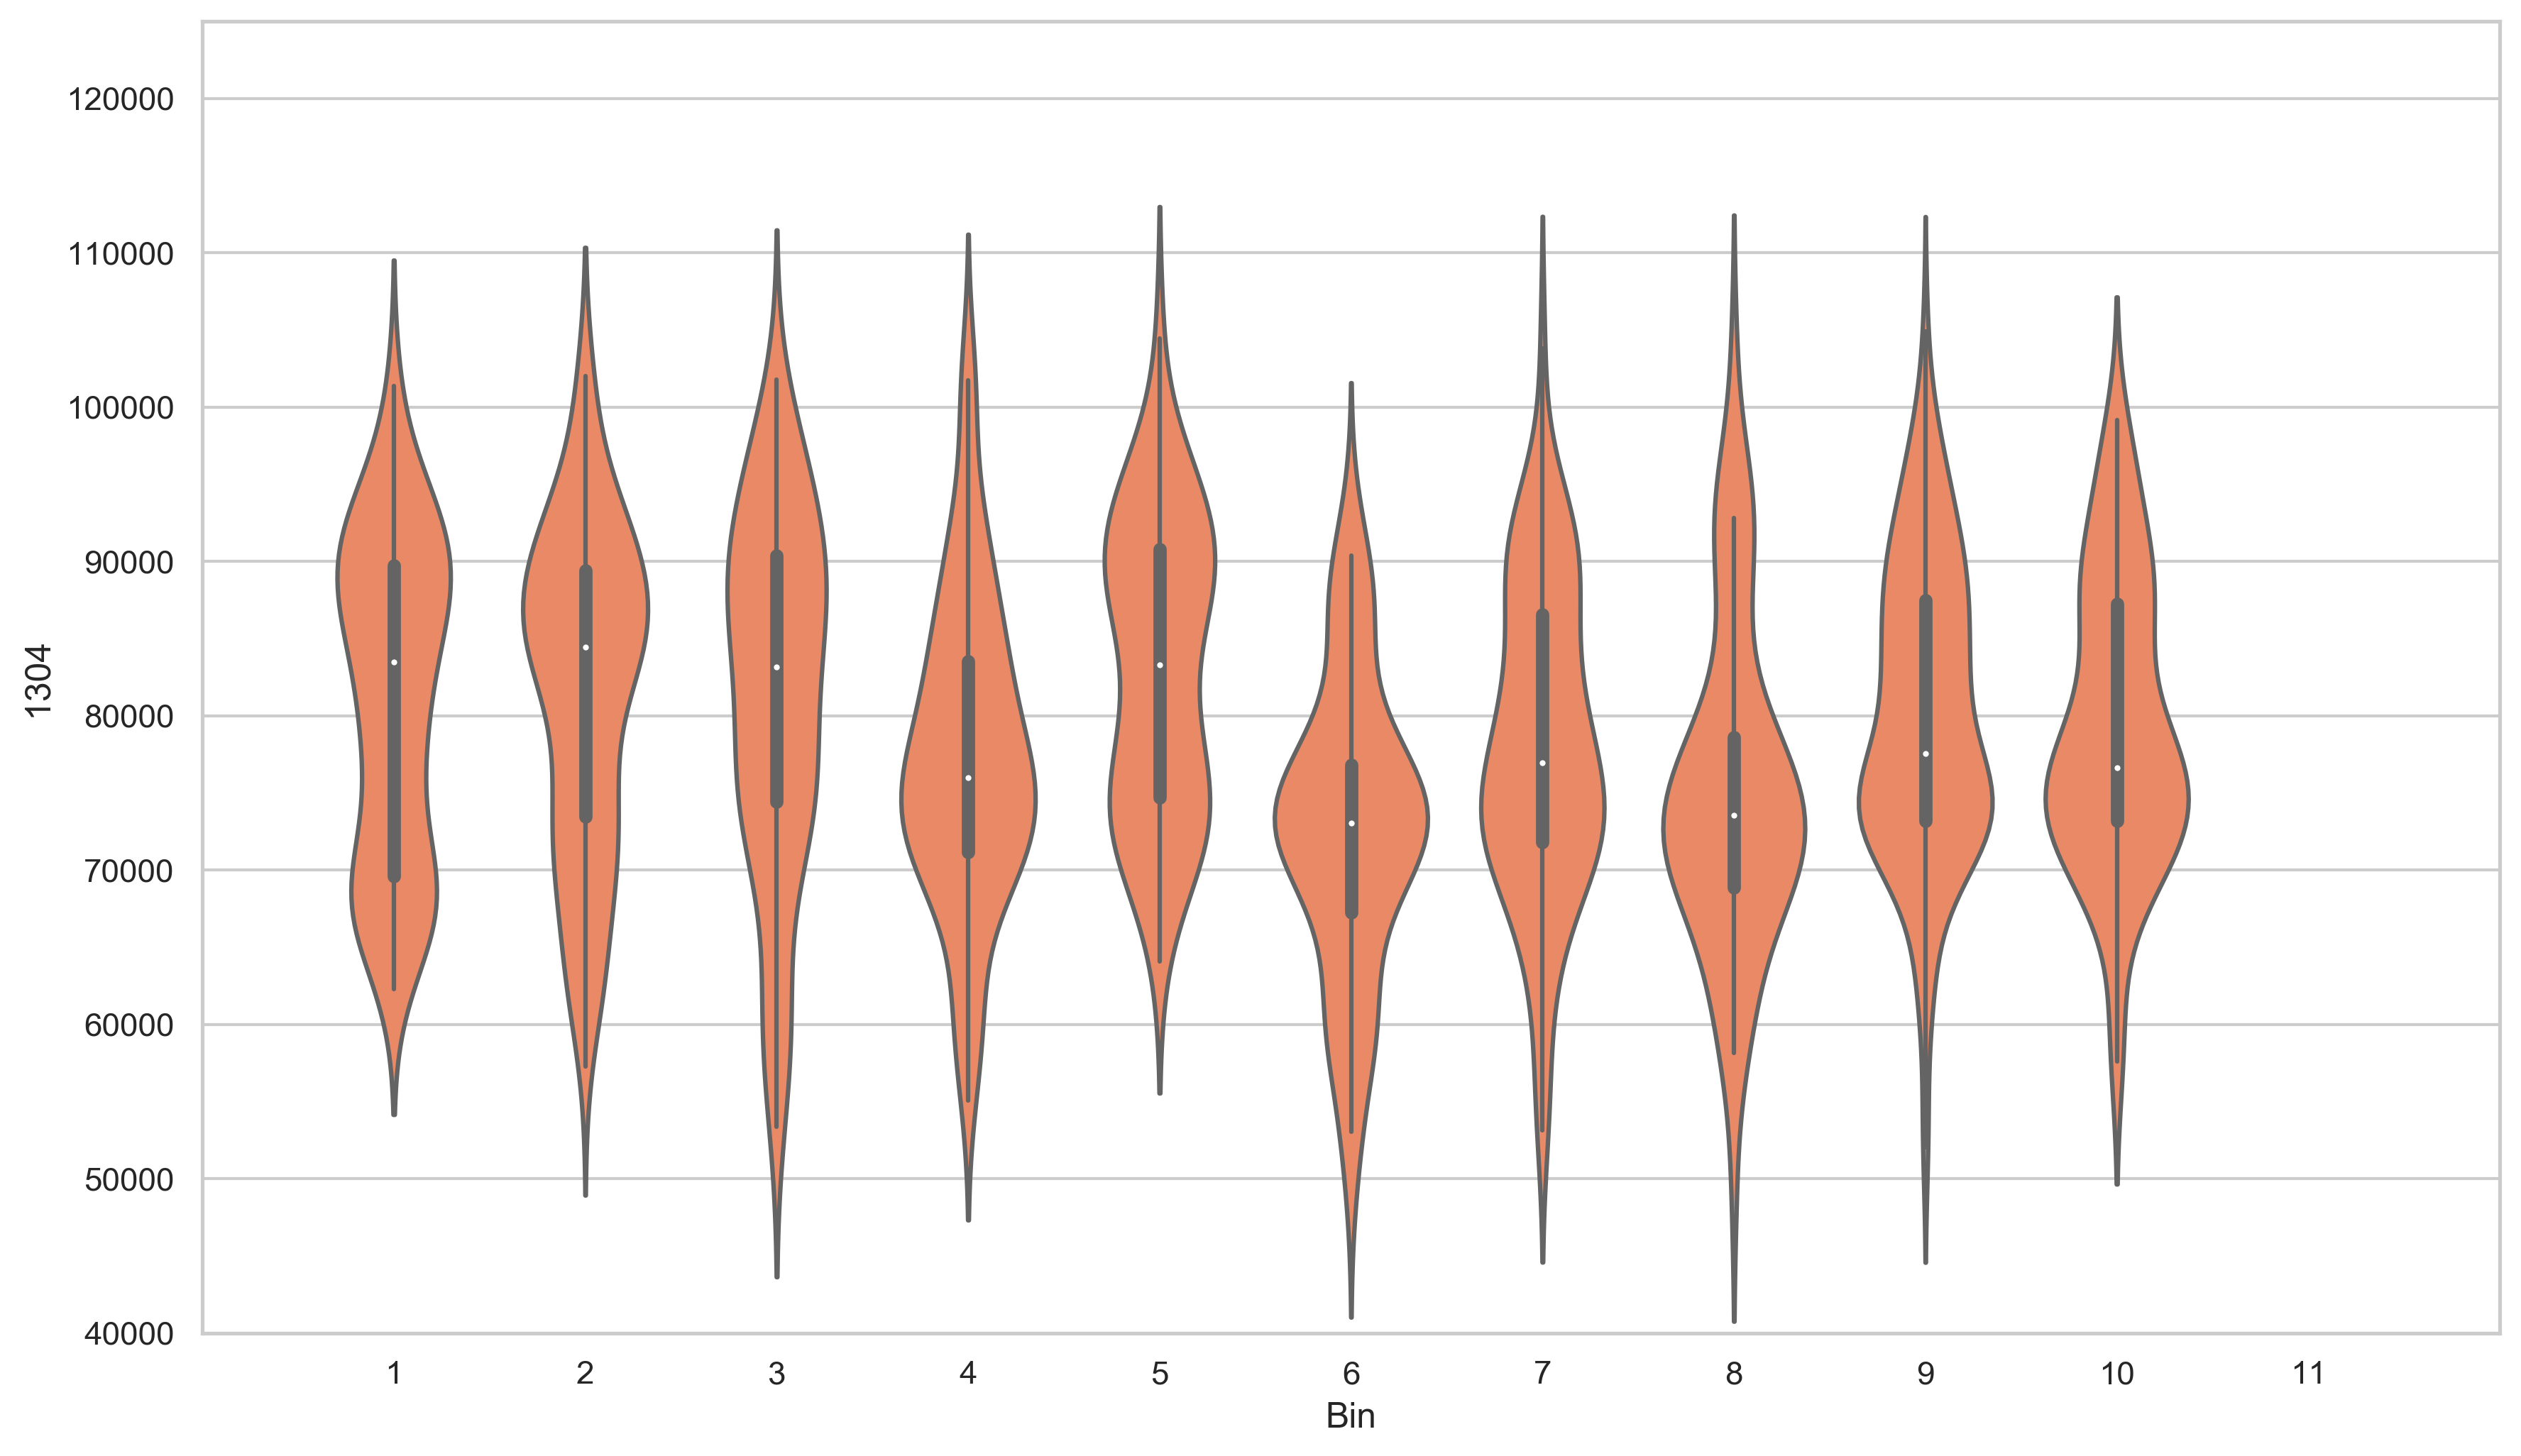

In [7]:










































# -- choose bin size in minutes (minimum = 1)
bin_size = 1

duration = object_data.recording_duration/60
bin_column = np.hstack(recording_df[['bin_number']].to_numpy())

split_array = get_split_indices_for_bin_size(bin_column, bin_size, duration)

data_column = np.hstack(recording_df[['avg_freq']].to_numpy())
data_split = split_data_by_indices(data_column, split_array)
mean_duration = pd.DataFrame([data for data in data_split]).T
mean_duration.index = np.arange(1, len(mean_duration)+1)
mean_duration.columns = np.arange(1,len(mean_duration.columns)+1)

sns.set(style="whitegrid", palette="muted", color_codes=True)
f, ax = plt.subplots(1, 1, figsize=(12, 7), dpi=300)

sns.violinplot(data=mean_duration, color="coral")

ax.set_xlabel('Bin')
ax.set_xlim(-1, object_data.recording_duration/60//bin_size+1)
ax.set_ylim(40000,125000)

ax.set_ylabel(object_data.recording_name[0:4], rotation=90)
# ax.set_yticks([])
plt.tight_layout()